In [ ]:
import numpy as np
import pandas as pd
import os
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
from collections import Counter
from sklearn import feature_extraction, model_selection, naive_bayes, metrics
from IPython.display import Image
import warnings
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler # to handle imbalanced data > 
from sklearn.model_selection import train_test_split # used to split data into traingin and testing
from sklearn.impute import SimpleImputer # used to address missnig values
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, LabelEncoder
# MinMax , RobustScalar  also - depends on yoour data, whichever suits your data best to get best result..
# to get between zero and 1 as mean of zero and a std dev of 1
from sklearn.compose import ColumnTransformer # used to apply transformation for selected columns
from sklearn.pipeline import Pipeline # used to create structured workflow for classification model
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier # used in this lab
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_curve, auc
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import mutual_info_classif, chi2
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, recall_score, precision_score # accuracy and classifiticion report, f1, recall, suuport all included in classificiotn report


warnings.filterwarnings("ignore")
%matplotlib inline  

## Step 1. Import the Data sets

The dataset was provided however is based off the [UCI Machine Learning Repository - Bank Marketing](
https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset/data )

a such we will interpret the columns based off the descriptions available from this site and from previous experience and exposure to this and related datasets.

There are two txt files
- 'trainingset.txt'
- 'queries.txt'

We 

we will import them an d

In [6]:
# imopiort trainign set 
# import query set
# Place the data set files and this notebook file in the same directory and the script should run fine.
print(os.getcwd())
path=os.getcwd()
file_path_train = os.path.join(path, 'trainingset.txt')
file_path_queries = os.path.join(path, 'queries.txt')


df_ts = pd.read_csv(file_path_train, sep = ",", encoding='latin-1')
df_qry = pd.read_csv(file_path_queries, sep = ",", encoding='latin-1')

# noticed soe whitespace in one of the feature names, so stripping whitespace and making all lower her to standardise the feature names across both training data and query dataset
# put all columns into lower and strip any qhite spaceshave 
df_ts.columns = df_ts.columns.str.strip().str.lower()
df_qry.columns = df_qry.columns.str.strip().str.lower()

print(df_ts.shape)

print(df_qry.shape)


e:\GG\Msc\ML_SPEC9270_bojan_thurs\github\ml_spec9270_bojan_thurs\assignments\working
(27272, 17)
(17939, 17)


In [7]:
df_ts.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,44,JobCat9,single,secondary,no,29,yes,no,unknown,5,may,0,1,-1,0,unknown,TypeA
1,47,JobCat3,married,unknown,no,1506,yes,no,unknown,5,may,0,1,-1,0,unknown,TypeA
2,31,unknown,single,unknown,no,1,no,no,unknown,5,may,0,1,-1,0,unknown,TypeA
3,26,JobCat6,single,tertiary,no,447,yes,yes,unknown,5,may,0,1,-1,0,unknown,TypeA
4,42,JobCat4,divorced,tertiary,yes,2,yes,no,unknown,5,may,0,1,-1,0,unknown,TypeA


In [8]:
df_qry.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,JobCat6,married,tertiary,no,2143,yes,no,unknown,5,may,0,1,-1,0,unknown,?
1,31,JobCat4,married,secondary,no,2,yes,yes,unknown,5,may,0,1,-1,0,unknown,?
2,33,JobCat6,married,tertiary,no,231,yes,no,unknown,5,may,0,1,-1,0,unknown,?
3,43,JobCat9,single,secondary,no,593,yes,no,unknown,5,may,0,1,-1,0,unknown,?
4,27,JobCat11,single,secondary,no,390,yes,no,unknown,5,may,0,1,-1,0,unknown,?


## Step 2. Data Exploration

### 2.1 - Check traingin and query dataset features names are identical

We will perform our initial exploratory data analysis on the train g set and once complete apply saame processing steps to the query data set before we run predictive model on the query data.

first aprt os to check frature names match across data sets  

In [9]:
# craete a list of feature names which we will compare
print(' === training data columns ===')
df_ts_col_name = (df_ts.columns.tolist())
print(df_ts_col_name)
print("\n")

# craete a list of qeury features names
print('=== query data columns ===')
df_qry_col_name = (df_qry.columns.tolist())
print(df_qry_col_name)
print("==== \n")

# compare the lists for tarinign and kquery to see if they match or not
if df_ts_col_name == df_qry_col_name:
    print( "training and query data set column names match")
else:
    print("column name mismatch")
    # we'll use sets to see what the differences are across the two lists
    ts_feature_set = set(df_ts_col_name)
    qry_feature_set = set(df_qry_col_name)
    print("=== features only in Train data set ===")
    print(ts_feature_set - qry_feature_set)
    print("\n")
    print(" ===features only in Query data set ===")
    print(qry_feature_set - ts_feature_set)

print(df_ts.shape)

print(df_qry.shape)

 === training data columns ===
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


=== query data columns ===
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
==== 

training and query data set column names match
(27272, 17)
(17939, 17)


#### 2.2 - Check data types per column

In [10]:
print(' === training data columns ===')
df_ts_dtypes= (df_ts.dtypes.tolist())
print(df_ts_dtypes)
print("\n")

print('=== query data columns ===')
df_qry_dtypes = (df_qry.dtypes.tolist())
print(df_qry_dtypes)
print("==== \n")

# we'll align the columns first to make sure the dtypes line up to the same columns in both datasets
aligned_cols = df_ts.columns.intersection(df_qry.columns)


dtypes_ts_qry = pd.DataFrame({
    'train_dtypes' : df_ts[aligned_cols].dtypes,
    'query_dtypes' : df_qry[aligned_cols].dtypes
    
})

print(dtypes_ts_qry)
print("==== \n ====")

dtype_diffs = dtypes_ts_qry[dtypes_ts_qry["train_dtypes"] != dtypes_ts_qry["query_dtypes"]]


# -->!
if dtype_diffs.empty:
    print( " === ** Training and Query data set dtypes match ** ===")
else:
    print("=== dtypes mismatch ===")
    print(dtype_diffs)

print(df_ts.shape)

print(df_qry.shape)

 === training data columns ===
[dtype('int64'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('int64'), dtype('O'), dtype('O'), dtype('O'), dtype('int64'), dtype('O'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('O'), dtype('O')]


=== query data columns ===
[dtype('int64'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('int64'), dtype('O'), dtype('O'), dtype('O'), dtype('int64'), dtype('O'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('O'), dtype('O')]
==== 

          train_dtypes query_dtypes
age              int64        int64
job             object       object
marital         object       object
education       object       object
default         object       object
balance          int64        int64
housing         object       object
loan            object       object
contact         object       object
day              int64        int64
month           object       object
duration         int64        int64

### 2.3 Create profiling report

we will now explore the training set data, initially by generatign a profiling report.

Any changes we make to the traing dataset we will subsequently apply to the query set to ensure alignment, but we will not mxi the two to prevemt data leakage

In [11]:
# starting off with a profile report
profile_ts = ProfileReport(df_ts)

In [12]:
profile_ts

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

### 2.4 - Visualise the Categorical Features

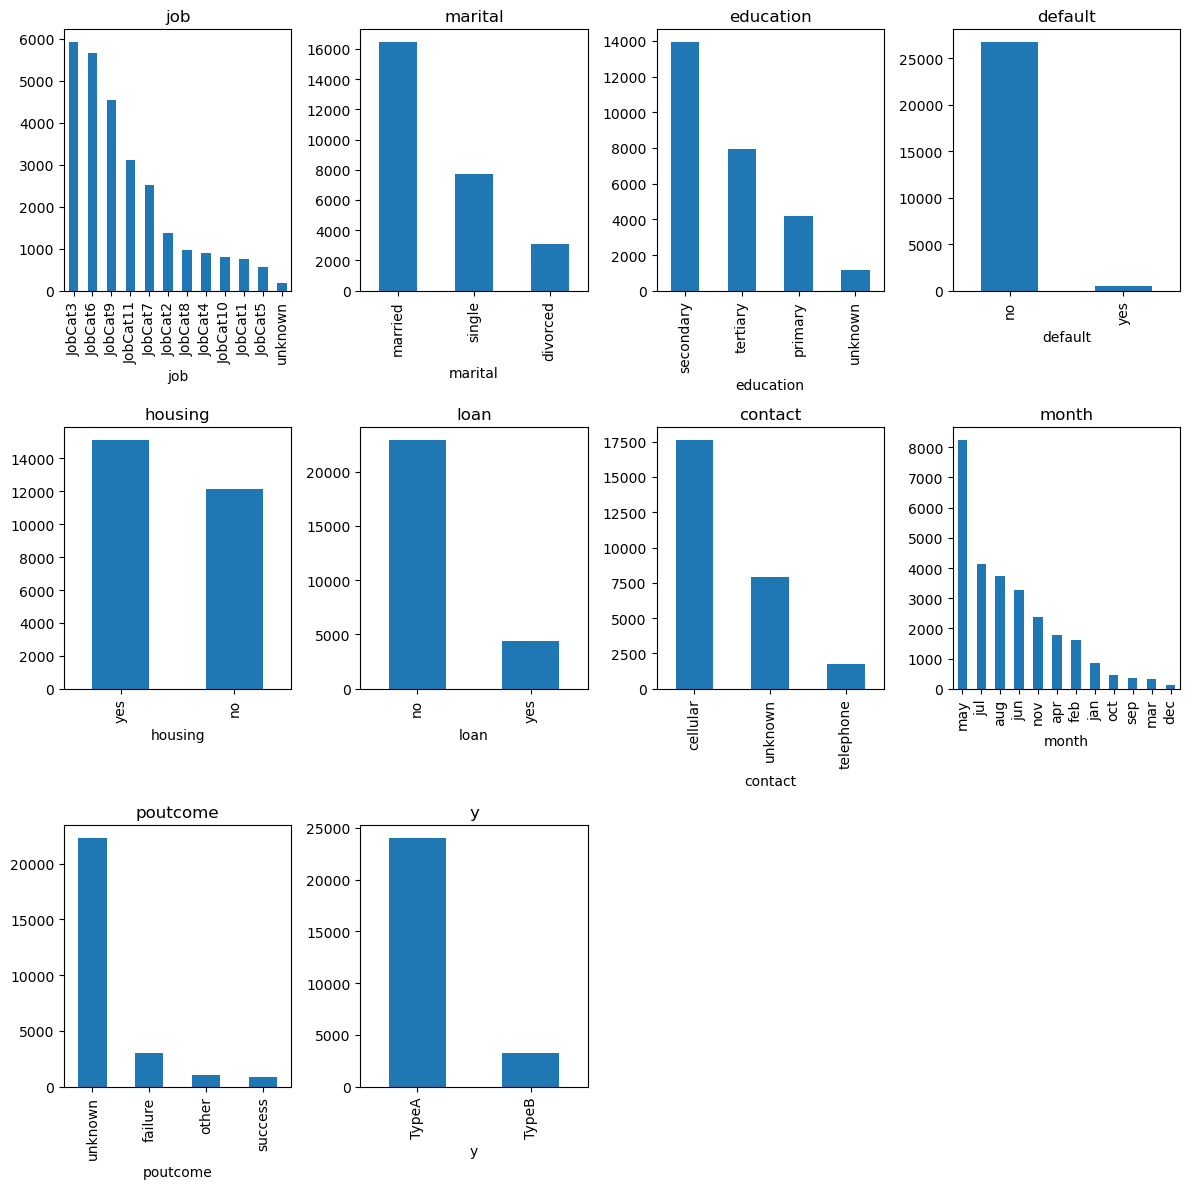

In [13]:
# Categorical Plots
# List of categorical columns
# categorical_columns = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

categorical_columns = df_ts.select_dtypes(include=['object']).columns

n_cols = 4  # define the number of columns

# now we check if the number of columns of that type is divisible by the number of columns we defined
if len(categorical_columns) % n_cols == 0:  # if it is divisible (no remainder)
    n_rows = int(len(categorical_columns) / n_cols)
else:  # if it is not divisible (remainder)
    n_rows = int(len(categorical_columns) / n_cols) + 1

# define the figure and its subplots
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 12))  # increased figsize for better view

cur_col = 0  # here we'll store the current column of the plot we are at
cur_row = 0  # here we'll store the current row of the plot we are at

# Iterate over the column's names
for column_name in categorical_columns:
    # Plot the value counts for each categorical column
    df_ts[column_name].value_counts().plot(kind='bar', ax=axes[cur_row, cur_col], title=column_name)
    
    # Move to the next column
    cur_col += 1
    
    # After, we must check we are still within the boundaries
    if cur_col == n_cols:  # if we are beyond the boundary:
        cur_row += 1  # move to the next row (i.e., increment the row count)
        cur_col = 0  # reset the count of columns (i.e., position at the first column)

# Remove unused axes (we are working with categorical columns here, so check for the number of categorical axes)
for ax in axes.flat[len(categorical_columns):]:
    ax.remove()

# Clean layout for a better look
plt.tight_layout()

# Display the plots
plt.show()

### 2.5 - Visaualise the Numerical features

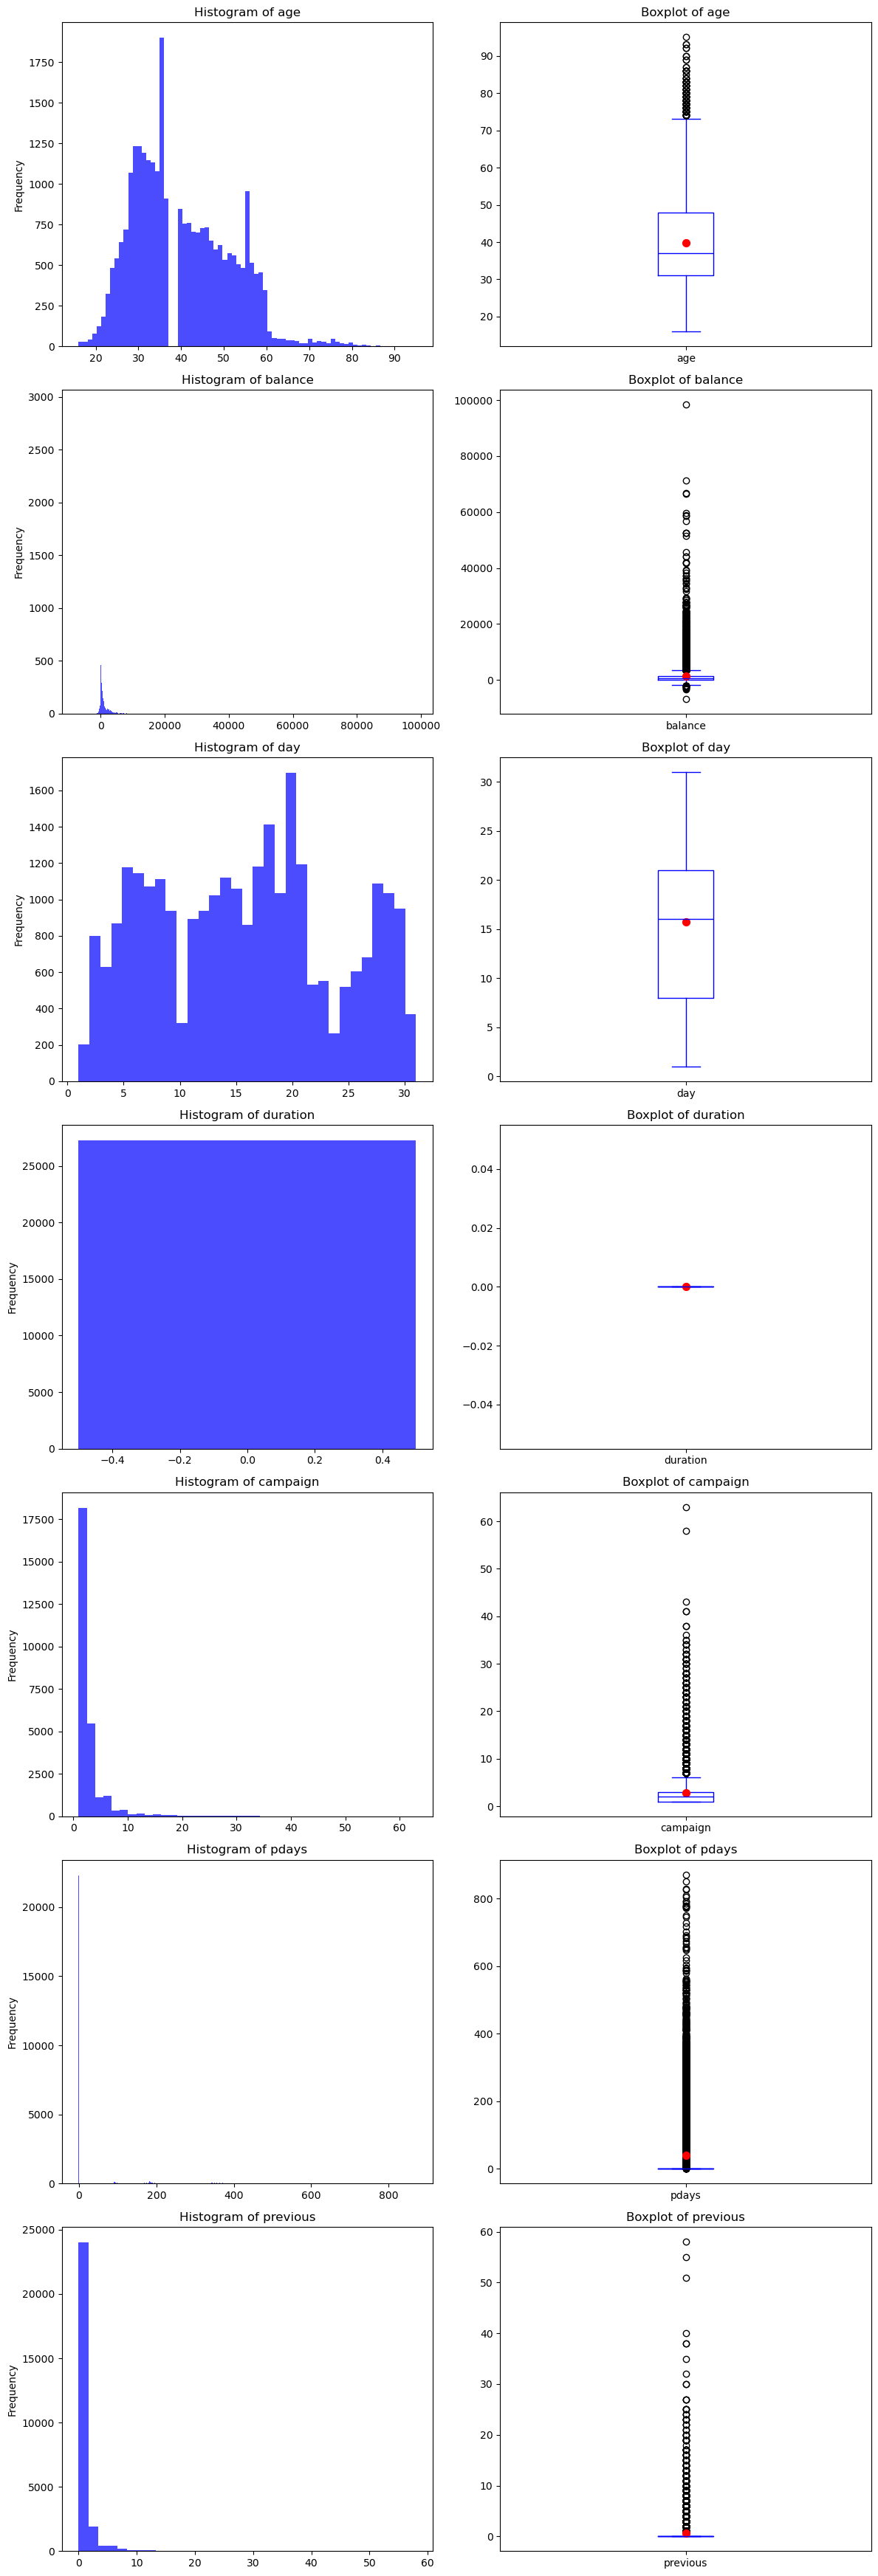

In [14]:
# Select numeric columns
## include=['number'] tells pandas to filter columns that have a numeric data type, i.e int64 or float64 as per above.
numeric_columns = df_ts.select_dtypes(include=['number']).columns

# create subplots: (# of rows,(number(len) of numeric columns) *2 columns one for histogram and one for boxplot. 
## Figsize here is doing 12 inches width and height is 5, but making it longer for the amount of numerical data hence len(numeric_columns)
fig, axes = plt.subplots(len(numeric_columns), 2, figsize=(12, 5 * len(numeric_columns)))

## enumerate() adds an index (starting from 0 by default) to an iterable.
### Each iteration assigns:
#### i The index (0, 1, 2, 3 etc.)
#### col: The column name 

for i, col in enumerate(numeric_columns):
    # Calculate mean for each varaible for use in the scatterplot below 
    
    mean_value = df_ts[col].mean()

    ### Note here for the hsitograms we are using the number of bins assocaited with nunque of the varaibles. 
    num_bins = df_ts[col].nunique()
    
    # Histogram: 50 bins, 70% transparcency, blue, put it in row(i) starting from 0 and col 0 so first column.
    df_ts[col].plot(kind='hist', bins=num_bins, alpha=0.7, color='b', ax=axes[i, 0])
    axes[i, 0].set_title(f'Histogram of {col}')

    # Boxplot (transposing it on its side and adding the mean per variable ina  scatter plot)
    df_ts[col].plot(kind='box', color='b', ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot of {col}')
    # Trying to get the boxplot to stay within th eimage, struggling with this part. 
    #axes[i, 1].set_xlim(bankdf[col].min() - 5, bankdf[col].max() + 5)
    # Adding scatterplit just ot have mean as a dot
    ## Z order is to overlay the mean on the graph kind of like ggplot2
    axes[i, 1].scatter(1,mean_value, color='red', s=50, zorder = 2) 

# Adjust layout
plt.tight_layout()
plt.show()

### 2.6 - View Training data structure, statistics and cleanliness

In [15]:
# lok at the data dtypes
print(df_ts.info())
print(df_ts.shape)
print(df_qry.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27272 entries, 0 to 27271
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        27272 non-null  int64 
 1   job        27272 non-null  object
 2   marital    27272 non-null  object
 3   education  27272 non-null  object
 4   default    27272 non-null  object
 5   balance    27272 non-null  int64 
 6   housing    27272 non-null  object
 7   loan       27272 non-null  object
 8   contact    27272 non-null  object
 9   day        27272 non-null  int64 
 10  month      27272 non-null  object
 11  duration   27272 non-null  int64 
 12  campaign   27272 non-null  int64 
 13  pdays      27272 non-null  int64 
 14  previous   27272 non-null  int64 
 15  poutcome   27272 non-null  object
 16  y          27272 non-null  object
dtypes: int64(7), object(10)
memory usage: 3.5+ MB
None
(27272, 17)
(17939, 17)


In [16]:
# view statistics for numerical data
print(df_ts.describe())
print(df_ts.shape)
print(df_qry.shape)

                age       balance           day  duration      campaign  \
count  27272.000000  27272.000000  27272.000000   27272.0  27272.000000   
mean      39.880463   1361.079459     15.769287       0.0      2.739623   
std       11.426248   3015.207142      8.300983       0.0      3.011097   
min       16.000000  -6847.000000      1.000000       0.0      1.000000   
25%       31.000000     73.000000      8.000000       0.0      1.000000   
50%       37.000000    447.000000     16.000000       0.0      2.000000   
75%       48.000000   1423.000000     21.000000       0.0      3.000000   
max       95.000000  98417.000000     31.000000       0.0     63.000000   

              pdays      previous  
count  27272.000000  27272.000000  
mean      40.074105      0.578872  
std      100.200984      1.942882  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%       -1.000000      0.000000  
max      871.000000     58.000000  


In [17]:
# quick look at data to see if its clean, no duplicates, null values unusual characters etc
# convert it to d first so can easily run some checks over it
# df_ts=pd.DataFrame(processed_per_file_data)
# view various dataframe details
# checking for null values and specific unknown values
print ("Rows     : " , df_ts.shape[0])
print ("Columns  : " , df_ts.shape[1])
print('------')
print ("\nFeatures : \n" , df_ts.columns.tolist())
print('------')
print ("\nMissing values :  ", df_ts.isnull().sum().values.sum())
print('------')
print ("\nMissing values per column:  ", df_ts.isnull().sum())
print('------')
print('\nnum of dups in df   =   {}'.format(df_ts.duplicated().sum()))
print('------')
print ("\nUnique values :  \n", df_ts.nunique())
print('------')
print('\n null values = ', df_ts.isnull().values.any())
print('------')
df_ts_missing = (df_ts=='?').sum()
print('\"  ?   \" values present =  \n',df_ts_missing)
print('------')
df_ts_unknown = (df_ts=='unknown').sum()
print('\"   unknown   \" values present =  \n',df_ts_unknown)
print('------')
df_ts_na = df_ts.isin(['N/A', 'N\\A', 'NA', 'n/a', 'n\\A', 'na', 'N_A']).sum()
print('    NA     values present = \n', df_ts_na)
print('------')
df_ts_none = df_ts.isin(['None', 'none']).sum()
print('    none    values present = \n', df_ts_none)
print('------')
# regex https://stackoverflow.com/questions/2124010/grep-regex-to-match-non-ascii-characters
# count of rows per column containing non-ascii characters
rogue_ascii_df = df_ts.apply(lambda s: s.astype(str).str.contains(r"[^\x00-\x7F]", regex=True, na=False).sum())
print("    non ascii chars   values present:\n", rogue_ascii_df)

Rows     :  27272
Columns  :  17
------

Features : 
 ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
------

Missing values :   0
------

Missing values per column:   age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64
------

num of dups in df   =   7
------

Unique values :  
 age            75
job            12
marital         3
education       4
default         2
balance      5939
housing         2
loan            2
contact         3
day            31
month          12
duration        1
campaign       41
pdays         499
previous       35
poutcome        4
y               2
dtype: int64
------

 null values =  False
------
"  ?   " values present = 

### 2.7 - Additional 'age' category analysis

In [18]:
# we will create a working eda dataframe for use here, so we keepthe original clean for future use

df_ts_eda = df_ts.copy()
df_qry_eda = df_qry.copy()

# Age category exploration - print number of uses in outlier categories
print(f"Number of users who were < 18 - training data -  {len(df_ts_eda[df_ts_eda['age'] < 18])}")
print(f"Number of users who were > 75 - training data {len(df_ts_eda[df_ts_eda['age'] > 75])}")


print(f"Number of users who were < 18 - query data {len(df_qry_eda[df_qry_eda['age'] < 18])}")
print(f"Number of users who were > 75 - query data  {len(df_qry_eda[df_qry_eda['age'] > 75])}")
# number who actually took out a term deposit in thse age bracket 

# only two unique valeus for term deposit 'yes' or 'no' - we'll filter on those per age group
print(f"Number of users who were < 18 who are typeB - {len(df_ts_eda[(df_ts_eda['age'] < 18) & (df_ts_eda['y'] == 'TypeB')])}")

print(f"Number of users who were > 75 who are typeB- {len(df_ts_eda[(df_ts_eda['age'] > 75 ) & (df_ts_eda['y'] == 'TypeB')])}")

print(df_ts.shape)
print(df_qry.shape)

Number of users who were < 18 - training data -  30
Number of users who were > 75 - training data 156
Number of users who were < 18 - query data 17
Number of users who were > 75 - query data  105
Number of users who were < 18 who are typeB - 9
Number of users who were > 75 who are typeB- 72
(27272, 17)
(17939, 17)


### 2.8 - Additional 'job' category value count analysis

In [19]:
# JOb category exploration - get job unique values count - we have 178 unknown - this could be unemployed or just not known... 
# we have no insight into categories within our dataset, so will leave 

print(df_ts_eda['job'].value_counts())

print(df_ts.shape)
print(df_qry.shape)

job
JobCat3     5927
JobCat6     5664
JobCat9     4539
JobCat11    3102
JobCat7     2510
JobCat2     1370
JobCat8      965
JobCat4      900
JobCat10     800
JobCat1      754
JobCat5      563
unknown      178
Name: count, dtype: int64
(27272, 17)
(17939, 17)


### 2.9 - Additional 'campaign' feature predictor analysis

In [20]:
# Campaign contact exploration - number of times a user was conacted against whether or not they resulted in TypeB outcome
# ths will assist in determining the predictot relevance in our dataset

# craete new feature is_typeB to styire if its tyupe B or not values
df_ts_eda['is_typeB'] = (df_ts_eda['y'] == 'TypeB').astype(int)

# updated bins — single contact gets its own bin
campaign_bins   = [0, 1, 5, 10, 20, 30, 40, 50, 64]
campaign_labels = ['1', '2-5', '6-10', '11-20', '21-30', '31-40', '41-50', '51-63']

# create a new feature to store the campaign bin  values
df_ts_eda['campaign_bin'] = pd.cut(df_ts_eda['campaign'], 
                                bins=campaign_bins, 
                                labels=campaign_labels, 
                                right=True)

# craete summary table to display output
campaign_summary = df_ts_eda.groupby('campaign_bin', observed=True).agg(
    total           = ('is_typeB', 'count'),
    converted       = ('is_typeB', 'sum'),
    conversion_rate = ('is_typeB', 'mean')
).reset_index()

campaign_summary['not_converted']   = campaign_summary['total'] - campaign_summary['converted']
campaign_summary['conversion_rate'] = (campaign_summary['conversion_rate'] * 100).round(2)

print(campaign_summary[['campaign_bin','total','converted',
                         'not_converted','conversion_rate']].to_string(index=False))

print(df_ts.shape)
print(df_qry.shape)


campaign_bin  total  converted  not_converted  conversion_rate
           1  10641       1569           9072            14.74
         2-5  14067       1526          12541            10.85
        6-10   1864        117           1747             6.28
       11-20    565         27            538             4.78
       21-30    107          2            105             1.87
       31-40     23          1             22             4.35
       41-50      3          0              3             0.00
       51-63      2          0              2             0.00
(27272, 17)
(17939, 17)


### 2.10 - Additional 'education' feature predictor analysis

In [21]:
# check how many type b values there are for each education type
# this is to help us determine fi we need to incldue ordinal nature of education and where unknown might sit

# TypeB conversion count and rate by education level
edu_summary = df_ts_eda.groupby('education').agg(
    total           = ('y', 'count'),
    typeB_count     = ('y', lambda x: (x == 'TypeB').sum()),
    typeA_count     = ('y', lambda x: (x == 'TypeA').sum()),
    conversion_rate = ('y', lambda x: round((x == 'TypeB').mean() * 100, 2))
).reset_index()

# sort by conversion rate descending
edu_summary = edu_summary.sort_values('conversion_rate', ascending=False)

print(edu_summary.to_string(index=False))

education  total  typeB_count  typeA_count  conversion_rate
 tertiary   7947         1216         6731            15.30
  unknown   1172          169         1003            14.42
secondary  13949         1494        12455            10.71
  primary   4204          363         3841             8.63


### 2.11 - Additional 'balance' feature predictor analysis

In [22]:
# balance and number of typeeA and type B outcomes
# will ook to se where most of type b's sit of if its an even spread across all balances
# we'll getth e totla per bucket / then percentage of the bucket thats in that range / then the number of type a and type B in that range
df_ts_eda['is_typeB'] = (df_ts_eda['y'] == 'TypeB').astype(int)

balance_bins   = [-7000, 0, 10000, 20000, 30000, 40000, 50000, 60000, 100000]
balance_labels = ['<0', '0-10k', '10k-20k', '20k-30k', 
                  '30k-40k', '40k-50k', '50k-60k', '60k+']

# create new feature to store the balance bin  values
df_ts_eda['balance_bin'] = pd.cut(df_ts_eda['balance'], 
                               bins=balance_bins, 
                               labels=balance_labels, 
                               right=True)

total_rows = len(df_ts_eda)

balance_summary = df_ts_eda.groupby('balance_bin', observed=True).agg(
    total       = ('is_typeB', 'count'),
    typeA_count = ('is_typeB', lambda x: (x == 0).sum()),
    typeB_count = ('is_typeB', 'sum'),
).reset_index()

# percentage of total in bucket that are typeB
balance_summary['typeB_pct_of_bucket'] = (balance_summary['typeB_count'] / 
                                           balance_summary['total'] * 100).round(2)

# percentage of whole dataset
balance_summary['bucket_pct_of_all']   = (balance_summary['total'] / 
                                           total_rows * 100).round(2)


# typeB_pct_of_bucket >  the percentage type b in the total in that blance range? i.e. for the 0-10k range 22367 is the total number of cstomers ni that balance  and typeB_pct_of_bucket is the percentage of that bucket that are typeB?
print(balance_summary[['balance_bin', 
                        'total',
                        'bucket_pct_of_all',
                        'typeA_count', 
                        'typeB_count',
                        'typeB_pct_of_bucket']].to_string(index=False))

# clean up
# df_ts = df_ts.drop(columns=['balance_bin'])

balance_bin  total  bucket_pct_of_all  typeA_count  typeB_count  typeB_pct_of_bucket
         <0   4412              16.18         4109          303                 6.87
      0-10k  22367              82.01        19512         2855                12.76
    10k-20k    386               1.42          320           66                17.10
    20k-30k     74               0.27           61           13                17.57
    30k-40k     15               0.06           12            3                20.00
    40k-50k      6               0.02            6            0                 0.00
    50k-60k      8               0.03            6            2                25.00
       60k+      4               0.01            4            0                 0.00


### 2.12 - Additional 'loan' feature predictor analysis

In [23]:
# 'loan' and number of typeA and type B outcomes
# will ook to se where most of type b's sit of if its an even spread across all loans values
# we'll getth e totla per bucket / then percentage of the bucket thats in that range / then the number of type a and type B in that range
df_ts_eda['is_typeB'] = (df_ts_eda['y'] == 'TypeB').astype(int)

total_rows = len(df_ts)

loan_summary = df_ts_eda.groupby('loan', observed=True).agg(
    total       = ('is_typeB', 'count'),
    typeA_count = ('is_typeB', lambda x: (x == 0).sum()),
    typeB_count = ('is_typeB', 'sum'),
).reset_index()

loan_summary['bucket_pct_of_all']    = (loan_summary['total'] / total_rows * 100).round(2)
loan_summary['typeB_pct_of_bucket']  = (loan_summary['typeB_count'] / loan_summary['total'] * 100).round(2)
loan_summary['typeA_pct_of_bucket']  = (loan_summary['typeA_count'] / loan_summary['total'] * 100).round(2)

print(loan_summary[['loan', 'total', 'bucket_pct_of_all',
                     'typeA_count', 'typeB_count',
                     'typeA_pct_of_bucket',
                     'typeB_pct_of_bucket']].to_string(index=False))

loan  total  bucket_pct_of_all  typeA_count  typeB_count  typeA_pct_of_bucket  typeB_pct_of_bucket
  no  22921              84.05        19974         2947                87.14                12.86
 yes   4351              15.95         4056          295                93.22                 6.78


### 2.13 - Additional 'contact' feature predictor analysis

In [24]:
# 'contact' and number of typeA and type B outcomes
# will ook to se where most of type b's sit of if its an even spread across all loans values
# we'll getth e totla per bucket / then percentage of the bucket thats in that range / then the number of type a and type B in that range
df_ts_eda['is_typeB'] = (df_ts_eda['y'] == 'TypeB').astype(int)

total_rows = len(df_ts_eda)

contact_summary = df_ts_eda.groupby('contact', observed=True).agg(
    total       = ('is_typeB', 'count'),
    typeA_count = ('is_typeB', lambda x: (x == 0).sum()),
    typeB_count = ('is_typeB', 'sum'),
).reset_index()

contact_summary['bucket_pct_of_all']   = (contact_summary['total'] / 
                                           total_rows * 100).round(2)
contact_summary['typeB_pct_of_bucket'] = (contact_summary['typeB_count'] / 
                                           contact_summary['total'] * 100).round(2)
contact_summary['typeA_pct_of_bucket'] = (contact_summary['typeA_count'] / 
                                           contact_summary['total'] * 100).round(2)

print(contact_summary[['contact', 'total', 'bucket_pct_of_all',
                        'typeA_count', 'typeB_count',
                        'typeA_pct_of_bucket',
                        'typeB_pct_of_bucket']].to_string(index=False))

  contact  total  bucket_pct_of_all  typeA_count  typeB_count  typeA_pct_of_bucket  typeB_pct_of_bucket
 cellular  17633              64.66        14942         2691                84.74                15.26
telephone   1742               6.39         1515          227                86.97                13.03
  unknown   7897              28.96         7573          324                95.90                 4.10


### 2.14 - Additional 'day' feature predictor analysis

In [25]:
# worth checking if day has any signal for TypeB
df_ts_eda['is_typeB'] = (df_ts_eda['y'] == 'TypeB').astype(int)
print(df_ts_eda.groupby('day')['is_typeB'].agg(['mean','count'])
      .rename(columns={'mean':'typeB_rate'})
      .round(3))

     typeB_rate  count
day                   
1         0.279    204
2         0.141    801
3         0.164    628
4         0.160    869
5         0.104   1179
6         0.098   1144
7         0.100   1072
8         0.107   1110
9         0.117    939
10        0.221    321
11        0.142    892
12        0.148    939
13        0.166   1022
14        0.110   1119
15        0.142   1060
16        0.151    859
17        0.093   1180
18        0.101   1413
19        0.068   1035
20        0.072   1697
21        0.091   1194
22        0.181    531
23        0.128    553
24        0.114    263
25        0.155    521
26        0.125    606
27        0.136    682
28        0.074   1087
29        0.073   1033
30        0.177    949
31        0.068    370


### 2.15 - Additional 'month' feature predictor analysis

In [26]:
# loan and number of typeeA and type B outcomes
# will ook to se where most of type b's sit of if its an even spread across all loans values
# we'll getth e totla per bucket / then percentage of the bucket thats in that range / then the number of type a and type B in that range
df_ts_eda['is_typeB'] = (df_ts_eda['y'] == 'TypeB').astype(int)

total_rows = len(df_ts_eda)

month_summary = df_ts_eda.groupby('month', observed=True).agg(
    total       = ('is_typeB', 'count'),
    typeA_count = ('is_typeB', lambda x: (x == 0).sum()),
    typeB_count = ('is_typeB', 'sum'),
    typeB_rate  = ('is_typeB', 'mean')
).reset_index()

month_summary['typeB_rate']   = (month_summary['typeB_rate'] * 100).round(2)
month_summary['pct_of_total'] = (month_summary['total'] / 
                                  total_rows * 100).round(2)

# sort by conversion rate descending
month_summary = month_summary.sort_values('typeB_rate', ascending=False)

print(month_summary[['month', 'total', 'pct_of_total',
                      'typeA_count', 'typeB_count',
                      'typeB_rate']].to_string(index=False))

month  total  pct_of_total  typeA_count  typeB_count  typeB_rate
  mar    308          1.13          143          165       53.57
  sep    371          1.36          197          174       46.90
  dec    124          0.45           68           56       45.16
  oct    451          1.65          250          201       44.57
  apr   1795          6.58         1429          366       20.39
  feb   1610          5.90         1335          275       17.08
  aug   3739         13.71         3322          417       11.15
  jan    841          3.08          756           85       10.11
  jun   3283         12.04         2951          332       10.11
  nov   2384          8.74         2149          235        9.86
  jul   4117         15.10         3754          363        8.82
  may   8249         30.25         7676          573        6.95


### 2.16 - Additional 'poutcome' feature predictor analysis

In [27]:
# poutcome and number of typeeA and type B outcomes
# will ook to se where most of type b's sit of if its an even spread across all loans values
# we'll getth e totla per bucket / then percentage of the bucket thats in that range / then the number of type a and type B in that range
# TypeB conversion by poutcome category
# TypeB conversion by poutcome category
df_ts_eda['is_typeB'] = (df_ts_eda['y'] == 'TypeB').astype(int)

total_rows = len(df_ts_eda)

poutcome_summary = df_ts_eda.groupby('poutcome', observed=True).agg(
    total       = ('is_typeB', 'count'),
    typeA_count = ('is_typeB', lambda x: (x == 0).sum()),
    typeB_count = ('is_typeB', 'sum'),
    typeB_rate  = ('is_typeB', 'mean')
).reset_index()

poutcome_summary['pct_of_total'] = (poutcome_summary['total'] / 
                                     total_rows * 100).round(2)

poutcome_summary['typeB_rate']   = (poutcome_summary['typeB_rate'] * 100).round(2)

poutcome_summary['typeA_pct']    = (poutcome_summary['typeA_count'] / 
                                     poutcome_summary['total'] * 100).round(2)

poutcome_summary['typeB_pct']    = (poutcome_summary['typeB_count'] / 
                                     poutcome_summary['total'] * 100).round(2)

# sort by conversion rate descending
poutcome_summary = poutcome_summary.sort_values('typeB_rate', ascending=False)

print(poutcome_summary[['poutcome', 'total', 'pct_of_total',
                         'typeA_count', 'typeA_pct',
                         'typeB_count', 'typeB_pct']].to_string(index=False))

poutcome  total  pct_of_total  typeA_count  typeA_pct  typeB_count  typeB_pct
 success    906          3.32          301      33.22          605      66.78
   other   1052          3.86          871      82.79          181      17.21
 failure   2998         10.99         2621      87.42          377      12.58
 unknown  22316         81.83        20237      90.68         2079       9.32


#### 2.17 - Feature Colinearity check 

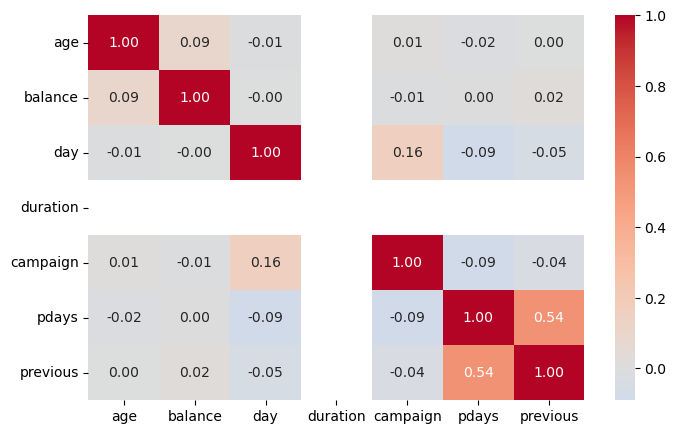

In [28]:
# Checking the correlations in numerical data - colinearity check
## Noting how the sign changed between pdays and previous now. 

# making correlation matrix
# corr_matrix=df_ts[numeric_columns].corr()
# corr_matrix

# we will sue orginal dataframe df_ts, as eda df has been modoified

NUM_COLS = df_ts.select_dtypes(include=['number']).columns.tolist()

corr_matrix = df_ts[NUM_COLS].corr()

# Seaborn graph of correlation matrix

fig , ax = plt.subplots(figsize = (8,5))
sns.heatmap(corr_matrix, annot = True, fmt='.2f', cmap='coolwarm', center=0,  ax=ax)

plt.tight_layout
plt.show()

### 2.18 -  Feature Analysis Results and Next Steps Outline


**NOTE:** This daatset is based of the [UCI Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing) data. We based our details and understanding of the individual features for this assignment as well as the details available for the **UCI Bank Marketing** data set.

we will look at them int he context of numerical and categorical features.

- **Numerical** 
    - 'age'
        - dtype = int64
        - no missing, corrupted of NaN values
        - min age = 16, max age = 95, 
        - Kurtosis ~ -0.05 / skewness ~ 0.59 / std dev ~ 11 / mean ~ 39 / median ~ 37
        - slight right skewness, with long tail to aged 95, not imbalanced and no extreme outliers.
        - Peak values land between 30 to 35 years old with IQR = 17, middle 50% of data between 31 and 48
        - There are nine typeB outcomes for customers under 16, but there may be legal issues anyway as to whether they are valid audience, if it were real world banking data predictive modelling. 
        - There are 72 TypeB outcomes for customers who are > 75. There is predictive value in this data.
        - The query data set has 17 customers < 16 years age. Given we need to have predictions for all rows in the query data set we will keep the < 18 age group in both training and query data. 
        - Next Step >>
            - assume normally distributed
            - Could apply Standard scalar (z score normalization - mean and std dev), but will apply RobustScalar (median + IQR) to keep the feature aligned with the use of RobustScalar on other features. 
            - dtype remains as int64

    - 'balance'
        - dtype = int64 
        - This is the balance in peoples bank accounts
        - no missing, corrupted of NaN values
        - min = -6847, max = 98417, with 2115 '0' values  
        - Kurtosis ~ 126 / skewness ~ 8 / std dev ~ 3015 / mean ~ 1361 / median ~ 447
        - Kurtosis is leptokurtic and highly right skewed... big peak near zero with long tail.. (normal distribution being = 3)
        - negative value is money owed.. big spread with extreme outliers
        - IQR = 1350, => middle 50% is tightly packed
        - Can see most sit int he 0-10K range, But the highest number of Type B outcomes are iny eh higher balance ranges i.e. 30-40K = 20% and 50-60K = 25%. While they have less customers in those brackets more of those customers have a type B outcome. 
        - From  business point of view that need to target more customers with higher bank balances to have greatest chance of getting type B outcomes.
        - log or robust scalar? - do nothing? if tree based model might be fine...
        - Next Steps
            - would benefit from being transformed 
            - Any transformation will also have to accommodate negative and zero values... as they are real data, real bank balances.
            - transform >> we could shift everything by adding 6848 to each value(addresses minus sign and zeros) + apply log1p + apply robust scalar
            - a simpler option may be to just handle outliers using Robust scalar (mean and IQR)
            - We will Scale using Robust Scalar.. it handles negative values and also zero values... not to shift and log transform.
            - It does not fix the skewness however, for RF and GB this is fine but for others i.e. LR, KNN, NB. may affect outcome. will test and try, see what works best.

    - 'day'
        - dtype = 'int64'
        - days of the month 
        - no missing, NaN, 'unknown', negative values, zeros, or corrupt data
        - min value 1 - max value  31
        - not a real numeric value, more categorical in that it represents a day of a month.
        - there are peaks and troughs which may correspond to weekends and busy days of the week, is periodic in behaviour.
        - no unusual imbalance to take account of
        - Kurtosis = ~ -1  (flat enough data no major peaks)/ skewwness = 0.096 (no skewness)
        - we could calculate the actual day of the week, as people could be more receptive on particular days of the week, however we do not have the year value to calculate it reliably, only date and month. Due to this uncertainty we will not feature engineer or add a time series component.
        - Next Steps
            - could one-hot encode but that would be adding dimensions with questionable return
            - will leave as is as int64 
            - will not scale as more categorical than numerical

    - 'duration'
        - dytype  = int64
        - how long a call lasted
        - 27272 values = '0' - no other values present, no variation or information in the data.
        - Also, we don't know before we make a call, how long that call will last, so the useful ness fo this feature is questionable.
        - Next Steps
            - we will remove the feature

    - 'campaign'
        - dtype  = 'int64'
        - number of times a user was contacted during this single campaign for which we have data.
        - no missing, NAN, zeros, negative numbers or corrupt data
        - min = 1  / max = 63 with 41 unique values. All whole numbers, no floats.
        - Kurtosis ~ 37 / skewness ~ 4 / std dev ~ 3 / mean ~ 2.7 / median ~ 2
        - 10,641 customers received only 1 call.
        - some customers were contacted up to 63 times in this campaign
        - not normally distributed - IQR - 1 to 3 but have low number outliers then out to '63'
        - sharp peak with kurtosis = 37.3 
        - long right tail with skewness of ~ 4
        - 1 contact  = ~ 14% outcome of TypeB - highest rate
        - 2 - 5 contacts = ~ 10% outcome of TypeB
        - nobody contacted > 40 times took out a term deposit and conversion rate gets less the more a user is contacted.... Ther is an inverse relationship between the number of times a customer is contacted and the number of customers taking out a term deposit. 
        - From a business perspective there is too much time in call centre ringing customers who will not buy. Worth reviewing the process based off this. If do not convert after a low, set number of contacts, do not ring them again.
        - Next Steps
            - leave dtype as is = int64
            - convert to log1p to address skewness and distribution
            - followed by Scaling using RobustScalar (media / IQR) to handle the outliers

    - 'pdays'
        - dtype = 'int64' 
        - number of days since client was last contacted in an earlier campaign (previous days)
        - No missing, corrupted or NaN values
        - 499 unique values
        - (22313 ) or 81.8% are '-1', other values, 18.2%, are spread across 498 different values, no one value dominates.
        - '-1' = never contacted before, so it has no numerical relationship to the other values in the feature. rather it is a flag, which means they haven't been contacted before and as such as new customers. 
        - IQR = 0 i.e. Q1, Q2 and Q3 are all -1. i.e. the top 75% of values are all '-1' 
        - The other values being a spread of small number of occurences of a large spread of values the max of which is '871'. These are old or existing customers, some of which have not been contacted in 1, 2 or more years.
        - Kurtosis ~ 7 (a sharp peak)/ skewness ~ 2.6 (right skewed)/ std dev ~ 100 / mean ~ 40 / median = -1
        - heavily right skewed, with a long tail, large spread of data
        - Not really a continuous set of numerical variables, its more of a categorical features, mixture of two sets of information. it is a flag as to whether or not previously contacted and then some variables representig duration since last contacted.  There are two different data dtypes in the feature.
        - Next Steps
            - Will split into new columns, 
                - column 1 (new) - 'contacted_previously' binary cetegorical  > 
                    - '1' = was contacted_previously 
                    - '0' = not contacted_previously
                    - dtype = int64 > will be binary numeric , but is categorical.
                - column 2 (existing column - Retain this column)
                    - Retain numbers of days since last contacted in this column as they are
                    - change the '-1' value to '0' to indicate customer has not been contacted before.
                    - dtype = 'int64' - leave as is i.e.'int64'
                    - Followed by applying 'log1p' natural log transformation to reduce the skewness and reshape the distribution, this will help logistical regression and naive bayes models with data shape and scaling
                    - followed by scaling using RobustScalar as we will have 22,313 '0' values 

    - 'previous'
        - dtype  = 'int64'
        - how many times a customer ws previously contacted.
        - no missing, negative, NaN or corrupt values
        - 35 distinct/unique values with, with a min = '0' and max = '58'
        - 81.8% (22313) are '0' which means never contacted before. This ties in with previous feature pdays which had 81.8% as '-1', meaning never contacted before, again as previously indicating new customers.
        - Kurtosis ~ 124 (a sharp peak)/ skewness ~ 8 (heavily right skewed)/ std dev ~ 1.9 / mean ~ 0.57 / median = 0
        - IQR = 0 => Q1, Q2 and Q3 are the same i.e. they are all '0'. i.e. at least 75% of values are all '0' and as can be designated as new customers.
        - Next Steps
            - dtype = 'int64' - leave as is i.e.'int64'
            - Scale by applying 'log1p' natural log transformation to reduce the skewness and reshape the distribution
            - followed by scaling using RobustScalar to address skewness


    




- **Categorical**
    - 'job'
        - dtype = 'object' 
        - customer job type
        - 12 unique job types and 178 'unknown' values = 12 categories in total
        - Jobs 3, 16 and 19 dominate - JobCat3=5927(21.7%) / JobCat6=5664(20.8%) / JobCat9=4539(16.6%)
        - no missing, NAN values or corrupted data
        - we have no insight into categories within our dataset, the dataset has been annonymised, if unemployed or not, or special category high paying jobs not available, as such will leave as is, including 'unknown' job category
        - Nest Steps
            - covert to binary categorical for each of the 12 categories - use one-hot encoding
            - Will increase dimensionality but no other option to convert to numerical without adding dimensions and there is predictive value in the feature
            - dtype changes to 'int64'

    - 'marital'
        - dtype = 'object' 
        - marital status of customer
        - no missing, NaN, 'unknown' or corrupt data
        - 3 unique values, - 'married'=16462(~60%) / 'single'=7728(~28%) / 'divorced'= 3082(~11%) = total 27272.
        - Is imbalanced but may reflect sample population from banking perspective i.e. middle aged married have most dealign with banks, mortgages etc
        - Next Steps
            - covert to binary categorical for each category - use one-hot encoding
            - dtype will be converted to binary numeric (but is effectively still a categorical and not numeric continuous)


    - 'education'
        - dtype = 'object'
        - education level for customer
        - no missing, NaN, 'unknown' or corrupt data
        - 4 unique values  - secondary=13,949(~51%) / tertiary=7,947 (~29%) / primary=4204 (~15%) / unknown=1172 (~ 4%)
        - no insight into "unknown" value - will keep this data as is, could be useful predictor
        - There is an ordinal element to the data with secondary being higher than primary and tertiary being higher than secondary, however where does unknown fit into hierarchy.
        - 'unknown' has the second highest typeb values, at ~ 11%, after tertiary, hence is important predictor.
        - Next Steps
            - will use one-hot encoding for all 4 categories
            - increases dimensions, however need to retain 'unknown' and doesn't quite fit into ordinal data structure easily.
            - dtype convert to = int64 (converted to binary numeric for each category (but is effectively still a categorical and not numeric continuous)

    - 'default'
        - dtype = 'object'
        - whether or not someone has previously defaulted on a loan.
        - no missing, NaN, 'unknown' or corrupt data
        - two categories - no=26788(98.2%) / yes=484(1.8%)
        - very imbalanced -
        - Real data so will keep even though heavily imbalanced
        - Next Steps
            - change 'yes' value to '1' and 'no' to '0'
            - convert to dtypes = int64 (although numeric is effectively binary categorical)
    
    - 'housing'
        - dtype = 'object'
        - Whether or not they own their own home
        - no missing, NaN, 'unknown' or corrupt data
        - reasonably balanced
        - 'yes' = 15131  / 'no'	= 12141 
        - Next Steps
            - change 'yes' value to '1' and 'no' to '0'
            - convert to dtypes = int64 (although numeric is effectively binary categorical)
    
    - 'loan'
        - dtype = 'object'
        - Whether or not they have an existing loan.
        - no missing, NaN, 'unknown' or corrupt data
        - is imbalanced
        - 'no'= 22921(84.0%) / 'yes'= 4351(16.0%)
        - 12% who have no loan are type B, whereas 6% who have loans are type B. Customers who do not have a loan are two times more ilkely to take out a term deposit and become type B customers. This makes sense as they have more disposable income.
        - Next Steps
            - change 'yes' value to '1' and 'no' to '0'
            - convert to dtypes = int64 (although numeric is effectively binary categorical)    

    - 'contact'
        - dtype = 'object'
        - How customers were contacted during the bank marketing campaign
        - no missing, NaN, 'unknown' or corrupt data
        - 3 values - cellular=17633 (64.7%)  /  unknown=7897(29.0%) /  telephone=1742(6.4%)
        - Imbalanced but are real values as most people do not have a land line, rather a mobile phone, the 'unknown' could be missing values, not recorded, possibly email or cold calling.
        - ~ 15% of cellular are type B, followed by ~11% for telephone and ~4% for unknown. With Cellular having the strongest performance.
        - could be related to age or a demographic younger people having mobile phones, and older people not adopting new technologies, as well as people being more open to engaging in different means of communication
        - Next Steps
            - will use one-hot encoding for all 3 categories
            - increases dimensions, however need to retain 'unknown' and doesn't quite fit into ordinal data structure easily.
            - dtype convert to = int64 (converted to binary numeric for each category (but is effectively still a categorical and not numeric continuous))
    
    - 'month'
        - dtype = 'object'
        - month of when contact was .
        - no missing, NaN, 'unknown' or corrupt data
        - big peak in May=8249(~30%), and then also in June, July=(4117(~ 15%)) / Aug=3729(~ 13%) and June=3283(12%)
        - big drop off in Sept=371(1.4%), Oct=451(1.7%) , Mar=308() and Dec 124()
        - Somewhat counter intuitive outcome from number of calls made
            - May = 8249 call made  > 573 (6.9%) resulted in TypeB outcome
            - Mar = 308 calls made > 165 (53.6%) resulted in TypeB outcome
            - explanations could be from a variety of factors, perhaps the customer type that ws rung, seasonal change of focus in customer, we do not have sufficient information to determine why this outcome is present. Regardless of cause month in this dataset adds a predictive value outside of the number of calls made.
        - There is some seasonality which may be a result of campaign duration
        - Next Steps
            - one-hot encoding for the months
            - will increase dimensionality but is a relevant feature with predictive value, as such the trade off should be worth this increase in dimensionality.
            - dtype convert to = int64 (converted to binary numeric for each category (but is effectively still a categorical and not numeric continuous))

    - 'poutcome'
        - dtype = 'object'
        - previous outcome of whether a customer took out a term deposit or not, so provides past customer outcome.
        - no missing, null or corrupt values etc
        - Imbalanced data - unknown=22316(81.8%)/ failure=2998(11.0%)/other=1052(3.9%)/success=906(3.3%)
        - 'unknown' is aligned with pdays value '-1' and previous value '0' i.e. in that it is not known previous outcome, there was no contact previously.
        - TYpeB outcome for customers who had success in previous campaign = 66% / other = 17.21% / failure = 12.58% / unknown  = 9.32%. 
        - 'success' is a very strong predictor in the dataset
        - 'Unknown' contains > 81% of the data, but has the lowest typeB outcome rate.
        - Next Step
            - one-hot encoding, binary columns.
            - drop_first=true for linear models to avoid multi colinearity - i.e. this will drop the first category to act as a reference grou, which is 'poutcome_unknown', no negative impact on RF, GB, KNN and NB
            - dtype =int64 - change dytpe after one-hot encoding
    
    - 'y'
        - dtype = 'object'
        - Our target variable  
        - TypeA = no sale / TypeB  = sale
        - 2 unique values -  TypeA=24030(88.1%) /  TypeB=3242(11.9%)
        - Most customers did not take out a term deposit, 
        - Is imbalanced
        - We need binary predictor for who will take out a term deposit i.e. want to predict TypeB customers, who will take out a term deposit. Will need to predict a minority class
        - if just predicted typeA for every customer we would get 88% accuracy, but that would not be useful to us, we need to predict the minority class of 11% type Bs.
        - Next Steps
            - will encode - map existing values as below, as models will work in numerical values, distances and probabilities and threshold values.
                - TypeA = 0
                - TypeB = 1
            - will use stratified split in train test split
            - will not encode query dataset target column
            - will using evaluation metrics such as F1 score, recall, precision, roc-auc 
            - wil consider using class_weight= 'balanced' / RandomOverSampler / SMOTE to improve minority class prediction
            - will change to 'int64' but remain a binary categorical feature 

NOTE: all feature scaling and transformations will be applied to both training (*df_ts*), and query (*df_qry*) datasets, **except** for target variable 'y'. We will not touch target variable 'y' on the query set.

Alos, we note that the correlation matrix shows some level fo colinearity between 'pdays' and 'previous', with a value of 0.54. While this is real it is not of a level as to warrant deletion of one of the elements at this stage, and as sch we will leave both for now. We will revisit if we have to.

## Step 3 - Pre-processing

### 3.1 - Outline Summary of Feature Actions

We will group the features by action t make it easier to see the groupings

- Removal
    - 'duration': delete feature


- 'pdays': 
    - create new feature 'contacted_previously' 
        - dtype = 'int64'
        - 1 = contacted previously 
        - 0 = not contacted previously
    - existing column
        - change '-1' value to zero + log transform using 'log1p'  + apply RobustScalar
        - name is same + dtype remains 'int64'


- Scale
    - 'age': apply RobustScalar + dtype remains as 'int64'
    - 'balance': apply RobustScalar + dtype remains as 'int64'
    - 'day': apply RobustScalar + dtype remains as 'int64'

- Log Transform then scale
    - 'campaign': log transform using 'log1p' + apply RobustScalar + dtype remains as 'int64'
    - 'previous': log transform using 'log1p' + apply RobustScalar + dtype remains as 'int64'

- One-Hot encoding
    - 'job': one-hot encoding for all 12 categories + dtype changes to 'int64'     
    - 'marital': one-hot encoding for 3 values 'married', 'single' and 'divorced' + dtype changes to 'int64'        
    - 'education': one-hot encoding for 4 values 'unknown', 'primary', 'secondary' and 'tertiary' + dtype changes to 'int64' 
    - 'contact': one-hot encoding for 3 values 'cellular', 'unknown' and 'telephone' + dtype changes to 'int64'  
    - 'month':  one-hot encoding for all 12 months + dtype changes to 'int64'                    
    - 'poutcome': one-hot encoding for 4 values 'unknown', 'failure', 'other' and 'success' + dtype changes to 'int64'    

- Convert text to Binary Numeric categorical
    - 'default': change 'yes' to 1 and 'no' to 0 + dtype changes to 'int64'         
    - 'housing': change 'yes' to 1 and 'no' to 0 + dtype changes to 'int64'       
    - 'loan': change 'yes' to 1 and 'no' to 0 + dtype changes to 'int64'  



- Training data only change
    - 'y': change 'TypeB' to 1 and 'TypeA' to 0 + dtype changes to 'int64'           

### 3.2 - Remove 'duration' feature



In [29]:
# we will remove duration feature
# we will apply transforms to both traingni and query datasets as we go, to keep them aligned. Except the target variable changes.

# firstly we will crate a new working dataframe that we will use, we can then return easily to a point in tme verison of it if we need.
# will base workign df off oroginal 

df_ts_1 = df_ts.copy()
df_qry_1 = df_qry.copy()

# delete then verify change in dataframe is as we expect
print(f' shape of training df = {df_ts_1.shape}')
df_ts_1 = df_ts_1.drop(['duration'], axis=1)
print(f' shape of training df after removal of duration feature  = {df_ts_1.shape}')

# delete then verify change in dataframe is as we expect
print("=============")
print(f' shape of query df = {df_qry_1.shape}')
df_qry_1 = df_qry_1.drop(['duration'], axis=1)
print(f' shape of query df after removal of duration featur = {df_qry_1.shape}')

 shape of training df = (27272, 17)
 shape of training df after removal of duration feature  = (27272, 16)
 shape of query df = (17939, 17)
 shape of query df after removal of duration featur = (17939, 16)


### 3.3 - Remove duplicates from training data only

In [30]:
# Seven duplicates were identified in earlier analysis we will remove these now. Duplicates may exist in query data, ona  quick check here we see there are 3 duplicates, as while these might increase compute demand or processing times, these are not signifcant in this scenario and they will have no affect on model performance. Also, the answer file expects a certain number of rows to eb returned and we woudl be out of sync with any answer file f we did so, resulting in potentially lower marks.

# create new workgin dataframe, not removing duplictes from query data
df_ts_2 = df_ts_1.copy()
df_qry_2 = df_qry_1.copy()

print(f' number of duplicates in training data = {df_ts_2.duplicated().sum()}')


print(f' shape of training df before dups remvevd= {df_ts_2.shape}')
df_ts_2 = df_ts_2.drop_duplicates()
print(f' shape of training df after dups removed = {df_ts_2.shape}')

print("=============")
print(f' number of duplicates in query data = {df_qry_2.duplicated().sum()}')
# print(f' shape of query df before dups remvevd = {df_qry_2.shape}')
# df_qry_2 = df_qry_2.drop_duplicates()
print(f' shape of query df the same as earlier not removing any duplicates = {df_qry_2.shape}')



 number of duplicates in training data = 7
 shape of training df before dups remvevd= (27272, 16)
 shape of training df after dups removed = (27265, 16)
 number of duplicates in query data = 3
 shape of query df the same as earlier not removing any duplicates = (17939, 16)


### 3.3 - Feature Engineering - Create new feature 'contacted_previously' from 'pdays' feature

In [31]:
# crate working df to use, we'll sue the same numbering for training and query so we know what each one contains if we need to roll back
df_ts_3 = df_ts_2.copy()
df_qry_3 = df_qry_2.copy()

# create new binary categorical feature named 'contacted_previously' which flags whether contacted previously or not from 'pdays' feature
# value equal to -1 is the flag that means not contacted before... so in new feature not contacted before will be = 0, contacted before = 1
# using a comparison operator to compare each value in pdays to '-1', returns true/false and we convert t/f to 1 and 0 using integers using int
df_ts_3['contacted_previously'] = (df_ts_3['pdays']!=-1).astype(int)
df_qry_3['contacted_previously'] = (df_qry_3['pdays']!=-1).astype(int)

# verify changes

contacted_previously_1_ts = (df_ts_3['contacted_previously'] == 1).sum()
contacted_previously_0_ts = (df_ts_3['contacted_previously'] == 0).sum()
contacted_previously_total_ts = len(df_ts_3['contacted_previously'])
contacted_previously_1_ts_pct = (contacted_previously_1_ts / contacted_previously_total_ts * 100).round(1)
contacted_previously_0_ts_pct = (contacted_previously_0_ts / contacted_previously_total_ts * 100).round(1)

contacted_previously_1_qry = (df_qry_3['contacted_previously'] == 1).sum()
contacted_previously_0_qry = (df_qry_3['contacted_previously'] == 0).sum()
contacted_previously_total_qry = len(df_qry_3['contacted_previously'])
contacted_previously_1_qry_pct = (contacted_previously_1_qry / contacted_previously_total_qry * 100).round(1)
contacted_previously_0_qry_pct = (contacted_previously_0_qry / contacted_previously_total_qry * 100).round(1)


print("==== verify changes - training data set =====")
print(f" \n the unique values in new df feature 'contacted previosul' = {df_ts_3['contacted_previously'].unique()}")
print(f' shape of training df before new feature added = {df_ts_2.shape}')
print(f' shape of training df after new feature added = {df_ts_3.shape}')
print(f" 'contacted_previously' values = '1'   (old non '-1' values ) = {contacted_previously_1_ts} /  {contacted_previously_1_ts_pct}%")
print(f" 'contacted_previously' values = '0'  (old '-1' values) = {contacted_previously_0_ts} / {contacted_previously_0_ts_pct}%")
print(f" total number of rows = {contacted_previously_total_ts}")
if contacted_previously_total_ts == contacted_previously_1_ts +contacted_previously_0_ts:
    print(" totals match = TRUE")
else:
    print("totals do not match = FALSE")
print(f" dtype = {df_ts_3['contacted_previously'].dtype}")

# verify changes Queryh dataset
print(" \n ==== verify changes - query data set =====")
print(f" \n the unique values in new df feature 'contacted previosul' = {df_qry_3['contacted_previously'].unique()}")
print(f' shape of training df before new feature added = {df_qry_2.shape}') # checkign previous df version
print(f' shape of training df after new feature added = {df_qry_3.shape}')
print(f" 'contacted_previously values' = '1'  (old non '-1' values ) = {contacted_previously_1_qry} /  {contacted_previously_1_qry_pct}%")
print(f" 'contacted_previously values' = '0' (old '-1' values) = {contacted_previously_0_qry} / {contacted_previously_0_qry_pct}%")
print(f" total rows = {contacted_previously_total_qry}")
if contacted_previously_total_qry == contacted_previously_1_qry + contacted_previously_0_qry:
    print(" totals match = TRUE")
else:
    print("totals do not match = FALSE")
print(f" dtype = {df_qry_3['contacted_previously'].dtype}")


==== verify changes - training data set =====
 
 the unique values in new df feature 'contacted previosul' = [0 1]
 shape of training df before new feature added = (27265, 16)
 shape of training df after new feature added = (27265, 17)
 'contacted_previously' values = '1'   (old non '-1' values ) = 4959 /  18.2%
 'contacted_previously' values = '0'  (old '-1' values) = 22306 / 81.8%
 total number of rows = 27265
 totals match = TRUE
 dtype = int32
 
 ==== verify changes - query data set =====
 
 the unique values in new df feature 'contacted previosul' = [0 1]
 shape of training df before new feature added = (17939, 16)
 shape of training df after new feature added = (17939, 17)
 'contacted_previously values' = '1'  (old non '-1' values ) = 3298 /  18.4%
 'contacted_previously values' = '0' (old '-1' values) = 14641 / 81.6%
 total rows = 17939
 totals match = TRUE
 dtype = int32


### 3.4 - 'pdays' updated > replace '-1' values in pdays with '0' values

In [ ]:
# crate working df to use, we'll sue the same numbering for training and query so we know what each one contains if we need to roll back
df_ts_4 = df_ts_3.copy()
df_qry_4 = df_qry_3.copy()

# replace all the '-1' values in 'pdays' feature with 0, indicating not previosuly contacted before.
df_ts_4['pdays'] = df_ts_4['pdays'].replace(-1, 0)
df_qry_4['pdays'] = df_qry_4['pdays'].replace(-1, 0)


# verify before and after values
pdays_minus_1_before_ts = (df_ts_3['pdays']==-1).sum()
pdays_minus_1_after_ts = (df_ts_4['pdays']==-1).sum()
pdays_zero_before_ts = (df_ts_3['pdays']==0).sum()
pdays_zero_after_ts = (df_ts_4['pdays']==0).sum()
pdays_not_zero_after_ts = (df_ts_4['pdays']!=0).sum()
pdays_total_num_rows_before_ts = (len(df_ts_3['pdays']))
pdays_total_num_rows_after_ts = (len(df_ts_4['pdays']))
pdays_zero_pct_ts = ((pdays_zero_after_ts /pdays_total_num_rows_after_ts) * 100).round(1)
pdays_not_zero_pct_ts = ((pdays_not_zero_after_ts /pdays_total_num_rows_after_ts) * 100).round(1)


# Verify changes in output

print("==== verify changes - training data set =====")

print(f" pdays minus 1 before {pdays_minus_1_before_ts}")
print(f" pdays minus 1 after {pdays_minus_1_after_ts}")
print(f" pdays zero before {pdays_zero_before_ts}")
print(f" pdays zero after {pdays_zero_after_ts}")
print(f" pdays total number of rows before {pdays_total_num_rows_before_ts}")
print(f" pdays total number of rows after {pdays_total_num_rows_after_ts}")
print(f" pdays zero percentage {pdays_zero_pct_ts}")
print(f" pdays not zero percentage {pdays_not_zero_pct_ts}")

# verify changes Query dataset

pdays_minus_1_before_qry = (df_qry_3['pdays']==-1).sum()
pdays_minus_1_after_qry = (df_qry_4['pdays']==-1).sum()
pdays_zero_before_qry = (df_qry_3['pdays']==0).sum()
pdays_zero_after_qry = (df_qry_4['pdays']==0).sum()
pdays_not_zero_after_qry = (df_qry_4['pdays']!=0).sum()
pdays_total_num_rows_before_qry = (len(df_qry_3['pdays']))
pdays_total_num_rows_after_qry = (len(df_qry_4['pdays']))
pdays_zero_pct_qry = ((pdays_zero_after_qry /pdays_total_num_rows_after_qry) * 100).round(1)
pdays_not_zero_pct_qry = ((pdays_not_zero_after_qry /pdays_total_num_rows_after_qry) * 100).round(1)
print(" \n ==== verify changes - query data set =====")

print(f" pdays minus 1 before {pdays_minus_1_before_qry}")
print(f" pdays minus 1 after {pdays_minus_1_after_qry}")
print(f" pdays zero before {pdays_zero_before_qry}")
print(f" pdays zero after {pdays_zero_after_qry}")
print(f" pdays total number of rows before {pdays_total_num_rows_before_qry}")
print(f" pdays total number of rows after {pdays_total_num_rows_after_qry}")
print(f" pdays zero percentage {pdays_zero_pct_qry}")
print(f" pdays not zero percentage {pdays_not_zero_pct_qry}")

==== verify changes - training data set =====
 pdays minus 1 before 22306
 pdays minus 1 after 0
 pdays zero before 0
 pdays zero after 22306
 pdays total number of rows before 27265
 pdays total number of rows after 27265
 pdays zero percentage 81.8
 pdays not zero percentage 18.2
 
 ==== verify changes - query data set =====
 pdays minus 1 before 14641
 pdays minus 1 after 0
 pdays zero before 0
 pdays zero after 14641
 pdays total number of rows before 17939
 pdays total number of rows after 17939
 pdays zero percentage 81.6
 pdays not zero percentage 18.4


### 3.5 - Binary conversion of 'default', 'housing' and 'loan' feature yes/no values to 1/0

In [33]:
# crate working df to use, we'll sue the same numbering for training and query so we know what each one contains if we need to roll back
df_ts_5 = df_ts_4.copy()
df_qry_5 = df_qry_4.copy()

# we'll define the columns names in a list item the the chaneg i a dictionary key pair mapping
# not equal to -1 is the flag that means not concated before... so not contctd before = 0, contacted before = 1
bin_col_names = ['default', 'housing', 'loan']
bin_kp_mapping = {'yes':1, 'no':0} # won't put parenthesis around nubers as woudl indicate a string value, want numerical int

for col in bin_col_names:
    df_ts_5[col] = df_ts_5[col].map(bin_kp_mapping)
    df_qry_5[col] = df_qry_5[col].map(bin_kp_mapping)

# verify change
print("========= verify training dataset  =====")

for col in bin_col_names:
    unique_ts = df_ts_5[col].unique()
    zeros_ts = (df_ts_5[col] == 0).sum()
    ones_ts = (df_ts_5[col] == 1).sum()
    total_ts =len (df_ts_5[col])
    print(f" training data - feature name = {col} - unique values = {unique_ts} /  0 = {zeros_ts} / 1s = {ones_ts} // total  = {total_ts}")

print(f" shape  = {df_ts_5.shape}")

print("========= query dataset shaep=====")
for col in bin_col_names:
    unique_qry = df_qry_5[col].unique()
    zeros_qry = (df_qry_5[col] == 0).sum()
    ones_qry = (df_qry_5[col] == 1).sum()
    total_qry =len (df_qry_5[col])
    print(f" query data - feature name = {col} - unique values = {unique_qry} / 0 = {zeros_qry} / 1s = {ones_qry} // total  = {total_qry}")

print(f" shape  = {df_qry_5.shape}")

========= verify training dataset  =====
 training data - feature name = default - unique values = [0 1] /  0 = 26781 / 1s = 484 // total  = 27265
 training data - feature name = housing - unique values = [1 0] /  0 = 12136 / 1s = 15129 // total  = 27265
 training data - feature name = loan - unique values = [0 1] /  0 = 22914 / 1s = 4351 // total  = 27265
 shape  = (27265, 17)
========= query dataset shaep=====
 query data - feature name = default - unique values = [0 1] / 0 = 17608 / 1s = 331 // total  = 17939
 query data - feature name = housing - unique values = [1 0] / 0 = 7940 / 1s = 9999 // total  = 17939
 query data - feature name = loan - unique values = [0 1] / 0 = 15046 / 1s = 2893 // total  = 17939
 shape  = (17939, 17)


### 3.6 - Binary conversion of target variable 'y' TypeA/TypeB values to 0/1 - Training Data Only

In [34]:
# **Only  done on training dataset**
# crate working df to use, we'll sue the same numbering for training and query so we know what each one contains if we need to roll back
# To keep the numberign in sync for both traingin and  query df, we will use thr _5 versio here i.e. nto create a new one
# df_ts_6 = df_ts_5.copy()
# df_qry_6 = df_qry_5.copy()

# we'll define the columns names in a list item the the chaneg i a dictionary key pair mapping
# not equal to -1 is the flag that means not concated before... so not contctd before = 0, contacted before = 1

print("========= view training dataset 'y' feature state '< before > changes =====")

print(f" unique values of y befor echanges = {df_ts_5['y'].unique()}")
print(len(df_ts_5['y']))
print((df_ts_5['y']=='TypeA').sum())
print((df_ts_5['y']=='TypeB').sum())

# change using map function to map values
df_ts_5['y'] = df_ts_5['y'].map({'TypeA':0, 'TypeB':1})
    
# verify change
print("========= verify training dataset  'y' feature < after > changes =====")

unique_y_ts = df_ts_5['y'].unique()
zeros_y_ts = (df_ts_5['y'] == 0).sum()
ones_y_ts = (df_ts_5['y'] == 1).sum()
nan_values_ts = (df_ts_5['y'].isna().sum())
total_y_ts =len (df_ts_5['y'])
print(f" training data - target feature name 'y' - \n unique values = {unique_y_ts} \n  0s present = {zeros_y_ts} \n 1s = {ones_y_ts} \n nan values present = {nan_values_ts} \n total  = {total_y_ts}")

print(f"training data shape  = {df_ts_5.shape}")



========= view training dataset 'y' feature state '< before > changes =====
 unique values of y befor echanges = ['TypeA' 'TypeB']
27265
24023
3242
========= verify training dataset  'y' feature < after > changes =====
 training data - target feature name 'y' - 
 unique values = [0 1] 
  0s present = 24023 
 1s = 3242 
 nan values present = 0 
 total  = 27265
training data shape  = (27265, 17)


### 3.7  - log transformation of 'balance', 'campaign', 'pdays', and 'previous'

In [35]:
neg_count = (df_qry['balance'] < 0).sum()
print(f"Number of negative balance values = {neg_count}")

zero_count = (df_qry['balance'] == 0).sum()
print(f"Number of negative balance values = {zero_count}")

Number of negative balance values = 1469
Number of negative balance values = 1399


### chi squared and cramer v

In [50]:
# ── show chi2, cramers V and p-values together ─────────
print("=== categorical feature importance — full analysis ===")
print()

# combine chi2 and cramers V into one table
combined_cat = pd.DataFrame({
    'chi2_score' : CHI_DF['chi2_score'],
    'p_value'    : CHI_DF['p_value'],
    'significant': CHI_DF['significant'],
    'cramers_v'  : cramers_df['cramers_v']
}).sort_values('cramers_v', ascending=False)

print(combined_cat.to_string())

print()
print("note: chi2 score inflated for 'contact' due to")
print("      large category volume differences")
print("      cramers V normalises for sample size")
print("      and gives more reliable ranking")
print("      poutcome correctly ranked first by cramers V")
print("      consistent with EDA (66.78% TypeB for success)")

=== categorical feature importance — full analysis ===

           chi2_score   p_value significant  cramers_v
poutcome        61.51  0.000000         YES     0.3191
month           25.34  0.000000         YES     0.2677
contact        796.67  0.000000         YES     0.1545
job              1.38  0.240589          NO     0.1393
education       62.57  0.000000         YES     0.0758
marital         22.65  0.000002         YES     0.0750

note: chi2 score inflated for 'contact' due to
      large category volume differences
      cramers V normalises for sample size
      and gives more reliable ranking
      poutcome correctly ranked first by cramers V
      consistent with EDA (66.78% TypeB for success)


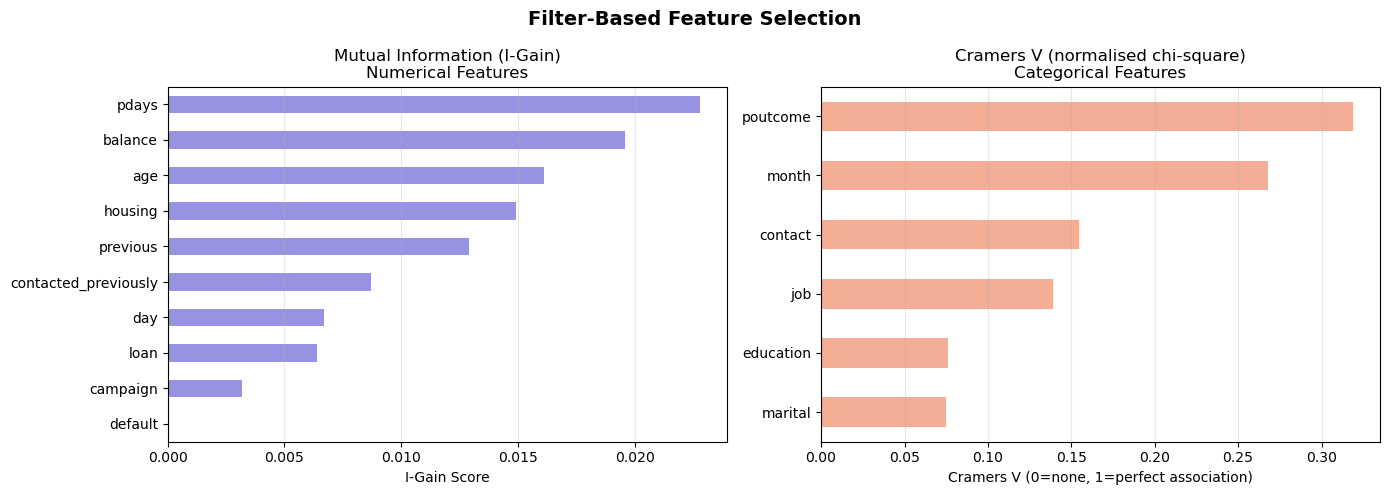

In [51]:
# most honest approach
# show cramers V as the plot
# mention chi2 in the writeup as the underlying test
# note that cramers V is derived from chi2 but normalised

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left — MI numerical
MI_DF.plot(kind='barh', ax=axes[0],
           color='#7F77DD', alpha=0.8, legend=False)
axes[0].set_title("Mutual Information (I-Gain)\nNumerical Features",
                   fontsize=12)
axes[0].set_xlabel('I-Gain Score')
axes[0].invert_yaxis()
axes[0].grid(alpha=0.3, axis='x')

# right — cramers V (derived from chi2, normalised)
cramers_df.plot(kind='barh', ax=axes[1],
                color='#F0997B', alpha=0.8, legend=False)
axes[1].set_title("Cramers V (normalised chi-square)\nCategorical Features",
                   fontsize=12)
axes[1].set_xlabel("Cramers V (0=none, 1=perfect association)")
axes[1].invert_yaxis()
axes[1].grid(alpha=0.3, axis='x')

plt.suptitle('Filter-Based Feature Selection',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [36]:
# crate working df to use, we'll sue the same numbering for training and query so we know what each one contains if we need to roll back
df_ts_6 = df_ts_5.copy()
df_qry_6 = df_qry_5.copy()

print(f"training data shape  = {df_ts_6.shape}")
print(f"query data shape  = {df_qry_6.shape}")


# natural log log1p 1p transforms 
# # campaign — min=1, no negatives or zeros, log1p safe directly
df_ts_6['campaign']  = np.log1p(df_ts_6['campaign'])
df_qry_6['campaign'] = np.log1p(df_qry_6['campaign'])

# pdays — -1 already replaced with 0 in step 3.4
# log1p(0) = 0 exactly — zeros handled cleanly
df_ts_6['pdays']  = np.log1p(df_ts_6['pdays'])
df_qry_6['pdays'] = np.log1p(df_qry_6['pdays'])

# previous — zero inflated, log1p(0)=0 cleanly
df_ts_6['previous']  = np.log1p(df_ts_6['previous'])
df_qry_6['previous'] = np.log1p(df_qry_6['previous'])

# ── verify ────────────────────────────────────────────
print("==== verify log1p transforms ====")
for col in ['campaign', 'pdays', 'previous']:
    print(f"\n--- {col} ---")
    # wil get the min values to check if the zeros have been handled
    print(f" df_ts_6  min={df_ts_6[col].min():.4f}  max={df_ts_6[col].max():.4f}  mean={df_ts_6[col].mean():.4f}")
    print(f" df_qry_6 min={df_qry_6[col].min():.4f}  max={df_qry_6[col].max():.4f}  mean={df_qry_6[col].mean():.4f}")
    print(f" any NaN df_ts_6  : {df_ts_6[col].isna().sum()}")
    print(f" any NaN df_qry_6 : {df_qry_6[col].isna().sum()}")

print(f"\ndf_ts_6  shape : {df_ts_6.shape}")
print(f"df_qry_6 shape : {df_qry_6.shape}")

training data shape  = (27265, 17)
query data shape  = (17939, 17)
==== verify log1p transforms ====

--- campaign ---
 df_ts_6  min=0.6931  max=4.1589  mean=1.1555
 df_qry_6 min=0.6931  max=4.0254  mean=1.1633
 any NaN df_ts_6  : 0
 any NaN df_qry_6 : 0

--- pdays ---
 df_ts_6  min=0.0000  max=6.7708  mean=0.9528
 df_qry_6 min=0.0000  max=6.7511  mean=0.9634
 any NaN df_ts_6  : 0
 any NaN df_qry_6 : 0

--- previous ---
 df_ts_6  min=0.0000  max=4.0775  mean=0.2261
 df_qry_6 min=0.0000  max=5.6204  mean=0.2268
 any NaN df_ts_6  : 0
 any NaN df_qry_6 : 0

df_ts_6  shape : (27265, 17)
df_qry_6 shape : (17939, 17)


### 3.8 Mutual information -feature importance - creation of pre-processor 

In [ ]:
# to calcujlat ethe mutual information we need to covnert any categorical features to numercial
# as we are doing that in te preprocessor later we will construct a pre-processor here before the main pre-processor to allwp us calculate the mutual infromation and importance of the predictive powers
# run this cell standalone without needing results dict



# redefine column lists
num_cols_pre_split = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'contacted_previously']

cat_cols_pre_split = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']

# rebuild preprocessor
preprocessor = ColumnTransformer([
    ('num', RobustScaler(), num_cols_pre_split),
    ('cat', OneHotEncoder(handle_unknown='ignore', 
                          drop='first'), cat_cols_pre_split)
])

# fit and transform on df_ts_6
# drop y first
X_mi = df_ts_6.drop(columns=['y'])
y_mi = df_ts_6['y']

X_encoded = preprocessor.fit_transform(X_mi)

# get feature names
num_names = num_cols_pre_split
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols_pre_split).tolist()

all_names = num_names + cat_names

print(f"total number of encoded features : {len(all_names)}")

# calculate Mutual information score
mi_scores = mutual_info_classif(X_encoded, y_mi, random_state=42)

mi_df = pd.DataFrame({
    'feature'  : all_names,
    'mi_score' : mi_scores.round(4)
}).sort_values('mi_score', ascending=False).reset_index(drop=True)

print("\n=== mutual information — all features after encoding ===")
print("higher score = more predictive signal for TypeB")
print()
print(mi_df.head(20).to_string(index=False))
print(f"\nbottom 5 weakest predictors:")
print(mi_df.tail(5).to_string(index=False))

total number of encoded features : 39

=== mutual information — all features after encoding ===
higher score = more predictive signal for TypeB

             feature  mi_score
    poutcome_success    0.0311
               pdays    0.0261
             balance    0.0197
    poutcome_unknown    0.0165
     contact_unknown    0.0152
                 age    0.0121
contacted_previously    0.0111
            previous    0.0109
           month_oct    0.0074
                 day    0.0071
      marital_single    0.0071
            campaign    0.0058
           month_may    0.0055
           month_jun    0.0054
           month_mar    0.0049
  education_tertiary    0.0049
         job_JobCat2    0.0043
      poutcome_other    0.0038
         job_JobCat3    0.0036
     marital_married    0.0034

bottom 5 weakest predictors:
          feature  mi_score
      job_JobCat4       0.0
contact_telephone       0.0
      job_unknown       0.0
      job_JobCat8       0.0
education_unknown       0.0


numerical features  : ['age', 'default', 'balance', 'housing', 'loan', 'day', 'campaign', 'pdays', 'previous', 'contacted_previously']
categorical features: ['job', 'marital', 'education', 'contact', 'month', 'poutcome']

=== mutual information — numerical features ===
measures non-linear relationship between feature and target

                      I-Gain
pdays                 0.0228
balance               0.0196
age                   0.0161
housing               0.0149
previous              0.0129
contacted_previously  0.0087
day                   0.0067
loan                  0.0064
campaign              0.0032
default               0.0000

=== chi-square — categorical features ===
measures statistical dependence between feature and target

           chi2_score   p_value significant
contact        796.67  0.000000         YES
education       62.57  0.000000         YES
poutcome        61.51  0.000000         YES
month           25.34  0.000000         YES
marital         22.65  0.00

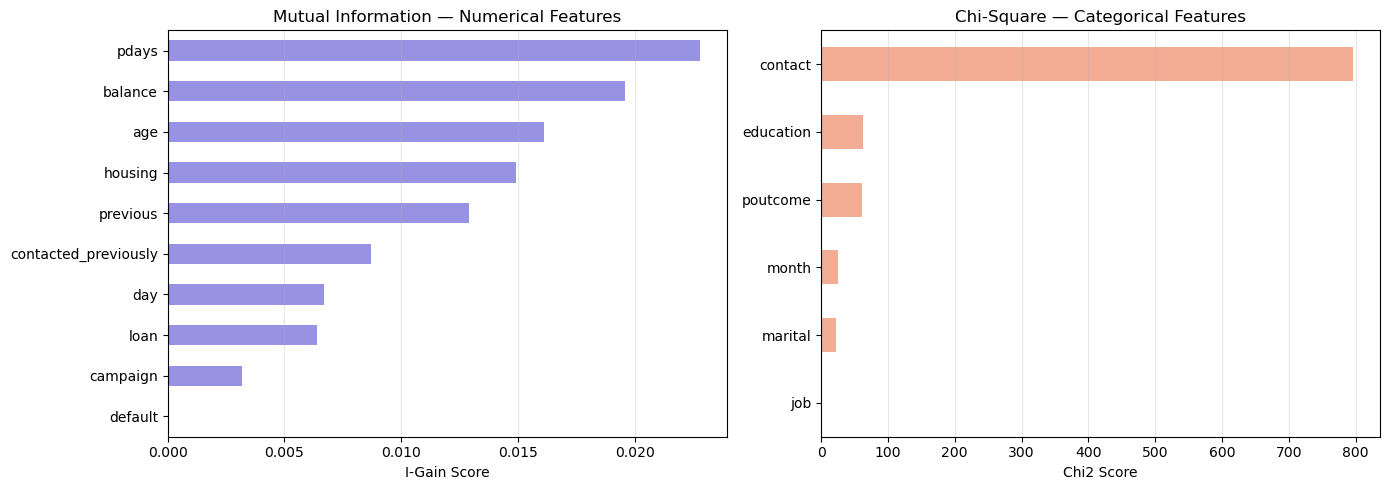


=== summary ===
strongest numerical predictor : pdays  (I-Gain=0.0228)
strongest categorical predictor: contact  (chi2=796.67)

all categorical features significant (p<0.05): False


In [45]:
### 2.19 - Filter-based Feature Selection
# mutual information for numerical features
# chi-square for categorical features
# aligns with lab solution approach

from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.preprocessing import LabelEncoder

# ── define feature groups from df_ts_6 ────────────────
# at this point:
#   numerical  = int64/float64 columns
#   categorical = object columns (still strings)
#   y already encoded as 0/1

num_cols_fs = df_ts_6.select_dtypes(
                include=['number']).drop(
                columns=['y']).columns.tolist()

cat_cols_fs = df_ts_6.select_dtypes(
                include=['object']).columns.tolist()

print(f"numerical features  : {num_cols_fs}")
print(f"categorical features: {cat_cols_fs}")

X_num = df_ts_6[num_cols_fs]
X_cat = df_ts_6[cat_cols_fs]
y_fs  = df_ts_6['y']

# ── mutual information — numerical features ───────────
print("\n=== mutual information — numerical features ===")
print("measures non-linear relationship between feature and target")
print()

i_scores = mutual_info_classif(X_num, y_fs, random_state=42)

MI_DF = pd.DataFrame(
    i_scores,
    index   = num_cols_fs,
    columns = ['I-Gain']
).sort_values('I-Gain', ascending=False).round(4)

print(MI_DF.to_string())

# ── chi-square — categorical features ────────────────
print("\n=== chi-square — categorical features ===")
print("measures statistical dependence between feature and target")
print()

# chi2 requires non-negative values
# label encode each categorical column
X_cat_encoded = X_cat.apply(LabelEncoder().fit_transform)

chi2_scores, p_values = chi2(X_cat_encoded, y_fs)

CHI_DF = pd.DataFrame({
    'chi2_score' : chi2_scores.round(2),
    'p_value'    : p_values.round(6),
    'significant': ['YES' if p < 0.05 else 'NO' for p in p_values]
}, index=cat_cols_fs).sort_values('chi2_score', ascending=False)

print(CHI_DF.to_string())

# ── visualise both ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# mutual information bar chart
MI_DF.plot(kind='barh', ax=axes[0], 
           color='#7F77DD', alpha=0.8, legend=False)
axes[0].set_title('Mutual Information — Numerical Features', fontsize=12)
axes[0].set_xlabel('I-Gain Score')
axes[0].invert_yaxis()
axes[0].grid(alpha=0.3, axis='x')

# chi-square bar chart
CHI_DF['chi2_score'].plot(kind='barh', ax=axes[1],
                           color='#F0997B', alpha=0.8)
axes[1].set_title('Chi-Square — Categorical Features', fontsize=12)
axes[1].set_xlabel('Chi2 Score')
axes[1].invert_yaxis()
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# ── summary ───────────────────────────────────────────
print("\n=== summary ===")
print(f"strongest numerical predictor : {MI_DF.index[0]}  "
      f"(I-Gain={MI_DF.iloc[0,0]})")
print(f"strongest categorical predictor: {CHI_DF.index[0]}  "
      f"(chi2={CHI_DF.iloc[0,0]})")
print(f"\nall categorical features significant (p<0.05): "
      f"{(CHI_DF['p_value'] < 0.05).all()}")

In [46]:
# cramers V normalises chi2 by sample size
# removes the distortion from large category counts
# gives a score between 0 and 1 like correlation

from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n    = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

print("=== cramers V — categorical features ===")
print("normalised association measure (0=none, 1=perfect)")
print()

cramers_results = {}
for col in cat_cols_fs:
    cv = cramers_v(df_ts_6[col], df_ts_6['y'])
    cramers_results[col] = round(cv, 4)

cramers_df = pd.DataFrame.from_dict(
    cramers_results, orient='index', columns=['cramers_v']
).sort_values('cramers_v', ascending=False)

print(cramers_df.to_string())

=== cramers V — categorical features ===
normalised association measure (0=none, 1=perfect)

           cramers_v
poutcome      0.3191
month         0.2677
contact       0.1545
job           0.1393
education     0.0758
marital       0.0750


=== forward sequential selection ===


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:  2.5min finished
Features: 1/7[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 out of   9 | elapsed:  1.3min finished
Features: 2/7[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:  1.0min finished
Features: 3/7[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:   58.6s finished
Features: 4/7[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of   6 | elapsed:   38.4s finished
Features: 5/7[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   31.6s finished
Features: 6/7[Parallel(n_jobs=-1)]: Using backend Lok

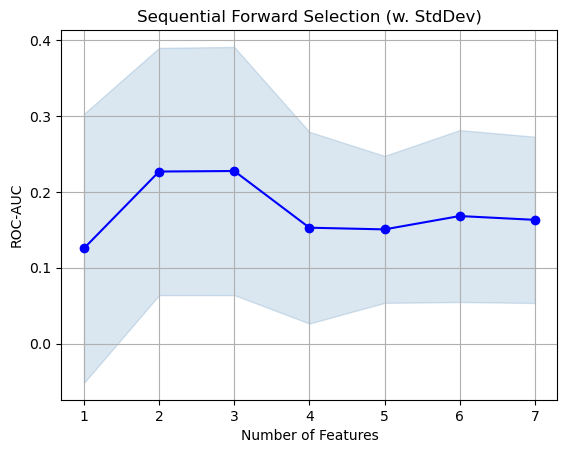


forward selected features:
  age
  default
  balance
  housing
  loan
  campaign
  contacted_previously

=== backward sequential elimination ===


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   58.7s finished
Features: 9/3[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 out of   9 | elapsed:   50.3s finished
Features: 8/3[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:   40.9s finished
Features: 7/3[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:   31.4s finished
Features: 6/3[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of   6 | elapsed:   30.8s finished
Features: 5/3[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   30.3s finished
Features: 4/3[Parallel(n_jobs=-1)]: Using backend Lok

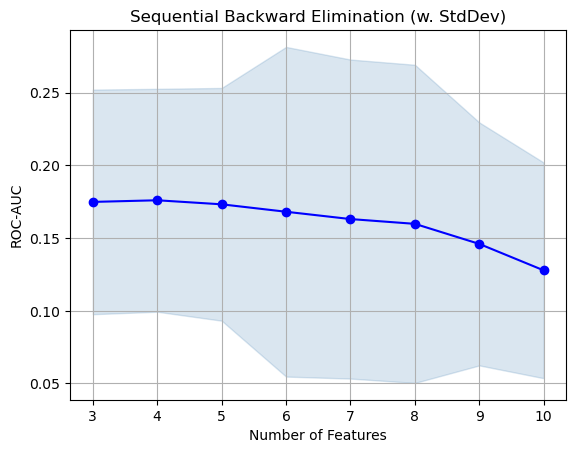


backward selected features:
  age
  balance
  housing

=== features selected by BOTH strategies ===
most robustly informative numerical features:
  age
  balance
  housing


In [48]:
# back forward  / SFS .. feature importance in groups... ch1 and cramer run on inepentvariables
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import RobustScaler

# scale numerical features — KNN is distance based
X_sfs = df_ts_6[num_cols_fs].values
y_sfs = df_ts_6['y'].values

X_sfs_scaled = RobustScaler().fit_transform(X_sfs)

knn = KNeighborsClassifier(n_neighbors=3)

# ── forward selection ──────────────────────────────────
print("=== forward sequential selection ===")
sfs_forward = SFS(knn,
                  k_features=7,
                  forward=True,
                  floating=False,
                  verbose=1,
                  scoring='f1',
                  cv=3,
                  n_jobs=-1)

sfs_forward = sfs_forward.fit(X_sfs_scaled, y_sfs)

fig1 = plot_sfs(sfs_forward.get_metric_dict(),
                ylabel='ROC-AUC', kind='std_dev')
plt.title('Sequential Forward Selection (w. StdDev)')
plt.grid()
plt.show()

print("\nforward selected features:")
for i in sfs_forward.k_feature_idx_:
    print(f"  {num_cols_fs[i]}")

# ── backward elimination ───────────────────────────────
print("\n=== backward sequential elimination ===")
sfs_backward = SFS(knn,
                   k_features=3,
                   forward=False,
                   floating=False,
                   verbose=1,
                   scoring='f1',
                   cv=3,
                   n_jobs=-1)

sfs_backward = sfs_backward.fit(X_sfs_scaled, y_sfs)

fig2 = plot_sfs(sfs_backward.get_metric_dict(),
                ylabel='ROC-AUC', kind='std_dev')
plt.title('Sequential Backward Elimination (w. StdDev)')
plt.grid()
plt.show()

print("\nbackward selected features:")
for i in sfs_backward.k_feature_idx_:
    print(f"  {num_cols_fs[i]}")

# ── overlap — most robustly informative features ───────
forward_idx  = set(sfs_forward.k_feature_idx_)
backward_idx = set(sfs_backward.k_feature_idx_)
overlap_idx  = forward_idx.intersection(backward_idx)

print(f"\n=== features selected by BOTH strategies ===")
print("most robustly informative numerical features:")
for i in sorted(overlap_idx):
    print(f"  {num_cols_fs[i]}")

In [49]:
# ── step 3: rerun with optimal k from plots ───────────
# forward  → peak at 2-3 features, use k=3
# backward → levels off around 4-5, use k=4

k_forward  = 3   # peak performance in forward plot
k_backward = 4   # performance levels off in backward plot

print(f"=== rerun with optimal k ===")
print(f"forward  k = {k_forward}  (peak F1 at 2-3 features)")
print(f"backward k = {k_backward} (F1 levels off at 4-5 features)")

sfs_forward_opt = SFS(knn,
                       k_features = k_forward,
                       forward    = True,
                       floating   = False,
                       verbose    = 0,
                       scoring    = 'f1',
                       cv         = 3,
                       n_jobs     = -1)

sfs_forward_opt.fit(X_sfs_scaled, y_sfs)

sfs_backward_opt = SFS(knn,
                        k_features = k_backward,
                        forward    = False,
                        floating   = False,
                        verbose    = 0,
                        scoring    = 'f1',
                        cv         = 3,
                        n_jobs     = -1)

sfs_backward_opt.fit(X_sfs_scaled, y_sfs)

# ── results ───────────────────────────────────────────
forward_feats  = set(sfs_forward_opt.k_feature_idx_)
backward_feats = set(sfs_backward_opt.k_feature_idx_)
overlap        = forward_feats.intersection(backward_feats)

print(f"\nforward selected ({k_forward} features):")
for i in sorted(forward_feats):
    print(f"  {num_cols_fs[i]}")

print(f"\nbackward selected ({k_backward} features):")
for i in sorted(backward_feats):
    print(f"  {num_cols_fs[i]}")

print(f"\n=== overlap — selected by BOTH strategies ===")
print("most robustly informative numerical features:")
for i in sorted(overlap):
    print(f"  {num_cols_fs[i]}")

=== rerun with optimal k ===
forward  k = 3  (peak F1 at 2-3 features)
backward k = 4 (F1 levels off at 4-5 features)

forward selected (3 features):
  default
  loan
  contacted_previously

backward selected (4 features):
  age
  default
  balance
  housing

=== overlap — selected by BOTH strategies ===
most robustly informative numerical features:
  default


In [39]:
# ── mutual information — numerical features only ───────
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# use df_ts_6 — preprocessed, before split
# categorical columns still object dtype at this point
# MI works on numerical only here
X_mi     = df_ts_6.select_dtypes(include=['number']).drop(columns=['y'])
y_mi     = df_ts_6['y']

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)

mi_df = pd.DataFrame({
    'feature'  : X_mi.columns,
    'mi_score' : mi_scores.round(4)
}).sort_values('mi_score', ascending=False).reset_index(drop=True)

print("=== mutual information scores — numerical features ===")
print("higher score = more predictive signal for TypeB")
print()
print(mi_df.to_string(index=False))

=== mutual information scores — numerical features ===
higher score = more predictive signal for TypeB

             feature  mi_score
               pdays    0.0228
             balance    0.0196
                 age    0.0161
             housing    0.0149
            previous    0.0129
contacted_previously    0.0087
                 day    0.0067
                loan    0.0064
            campaign    0.0032
             default    0.0000


### 3.8 Train / Test split and pipeline

In [ ]:
df_ts_7 = df_ts_6.copy()
df_qry_7 = df_qry_6.copy()

# separate features and target
X = df_ts_6.drop(columns=['y'])
y = df_ts_6['y']

# numerical features at this point
# balance, age, day go to RobustScaler
# campaign, pdays, previous already log1p transformed
# contacted_previously is binary 0/1 — still scale for LR/KNN
num_cols_pre_split = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'contacted_previously']

# categorical features — one-hot encode in pipeline
cat_cols_pre_split = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']

print(f"X shape     : {X.shape}")
print(f"y shape     : {y.shape}")
print(f"num_cols_pre_split    : {num_cols_pre_split}")
print(f"cat_cols_pre_split    : {cat_cols_pre_split}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(y.value_counts(normalize=True).round(3))

# stratified 80/20 split — preserves 88/12 class ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"\nX_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test  shape : {y_test.shape}")

# verify stratification preserved class ratio
print(f"\ny_train class ratio:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\ny_test class ratio:")
print(y_test.value_counts(normalize=True).round(3))


X shape     : (27265, 16)
y shape     : (27265,)
num_cols_pre_split    : ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'contacted_previously']
cat_cols_pre_split    : ['job', 'marital', 'education', 'contact', 'month', 'poutcome']

Target distribution:
y
0    24023
1     3242
Name: count, dtype: int64
y
0    0.881
1    0.119
Name: proportion, dtype: float64

X_train shape : (21812, 16)
X_test  shape : (5453, 16)
y_train shape : (21812,)
y_test  shape : (5453,)

y_train class ratio:
y
0    0.881
1    0.119
Name: proportion, dtype: float64

y_test class ratio:
y
0    0.881
1    0.119
Name: proportion, dtype: float64


### 3.9 Build Pipeline and train 5 models

In [ ]:
# preprocessor using RobustScaler on numerical, OneHotEncoder on categorical fitted on X_train only, doesn't see X_test during fit
preprocessor = ColumnTransformer([
    ('num', RobustScaler(), num_cols_pre_split),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols_pre_split)])

# define 5 models
models = {
    'Logistic Regression'  : LogisticRegression(
                                class_weight='balanced', 
                                max_iter=500,
                                random_state=42),
    'Random Forest'        : RandomForestClassifier(
                                class_weight='balanced',
                                n_estimators=200,
                                random_state=42),
    'Gradient Boosting'    : GradientBoostingClassifier(
                                n_estimators=200,
                                random_state=42),
    'KNN'                  : KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes'          : GaussianNB()
}

# store results for comparison
results = {}

print("=" * 60)
print("MODEL TRAINING AND EVALUATION")
print("=" * 60)

for name, model in models.items():
    # build pipeline — preprocessor + classifier
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier',   model)
    ])
    
    # fit on training data only
    pipe.fit(X_train, y_train)
    
    # predict on test data
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    # calculate metrics
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    # store results
    results[name] = {
        'pipe'    : pipe,
        'accuracy': acc,
        'f1'      : f1,
        'roc_auc' : auc,
        'y_pred'  : y_pred,
        'y_prob'  : y_prob
    }
    
    # print results
    print(f"\n{'─' * 60}")
    print(f"Model    : {name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, 
                                target_names=['TypeA','TypeB']))
    print(f"Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

# ── summary comparison table ──────────────────────────
print(f"\n{'=' * 60}")
print("SUMMARY COMPARISON")
print(f"{'=' * 60}")
print(f"{'Model':<25} {'Accuracy':>10} {'F1':>10} {'ROC-AUC':>10}")
print(f"{'─' * 55}")
for name, res in sorted(results.items(), 
                         key=lambda x: x[1]['roc_auc'], 
                         reverse=True):
    print(f"{name:<25} {res['accuracy']:>10.4f} "
          f"{res['f1']:>10.4f} {res['roc_auc']:>10.4f}")

# ── identify best model ───────────────────────────────
best_name = max(results, key=lambda k: results[k]['roc_auc'])
print(f"\nBest model by ROC-AUC : {best_name}")
print(f"ROC-AUC               : {results[best_name]['roc_auc']:.4f}")
print(f"F1 Score              : {results[best_name]['f1']:.4f}")


MODEL TRAINING AND EVALUATION

────────────────────────────────────────────────────────────
Model    : Logistic Regression
Accuracy : 0.7539
F1 Score : 0.3799
ROC-AUC  : 0.7660

Classification Report:
              precision    recall  f1-score   support

       TypeA       0.94      0.77      0.85      4805
       TypeB       0.27      0.63      0.38       648

    accuracy                           0.75      5453
   macro avg       0.61      0.70      0.61      5453
weighted avg       0.86      0.75      0.79      5453

Confusion Matrix:
[[3700 1105]
 [ 237  411]]

────────────────────────────────────────────────────────────
Model    : Random Forest
Accuracy : 0.8892
F1 Score : 0.2993
ROC-AUC  : 0.7762

Classification Report:
              precision    recall  f1-score   support

       TypeA       0.90      0.98      0.94      4805
       TypeB       0.60      0.20      0.30       648

    accuracy                           0.89      5453
   macro avg       0.75      0.59      0.62 

In [42]:
# ── rebuild preprocessor independently ────────────────
# run this cell standalone without needing results dict

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import numpy as np

# redefine column lists
num_cols_pre_split = ['age', 'balance', 'day', 'campaign', 
                      'pdays', 'previous', 'contacted_previously']

cat_cols_pre_split = ['job', 'marital', 'education', 
                      'contact', 'month', 'poutcome']

# rebuild preprocessor
preprocessor = ColumnTransformer([
    ('num', RobustScaler(), num_cols_pre_split),
    ('cat', OneHotEncoder(handle_unknown='ignore', 
                          drop='first'), cat_cols_pre_split)
])

# fit and transform on df_ts_6
# drop y first
X_mi = df_ts_6.drop(columns=['y'])
y_mi = df_ts_6['y']

X_encoded = preprocessor.fit_transform(X_mi)

# get feature names
num_names = num_cols_pre_split
cat_names = preprocessor\
            .named_transformers_['cat']\
            .get_feature_names_out(cat_cols_pre_split).tolist()

all_names = num_names + cat_names

print(f"total encoded features : {len(all_names)}")

# calculate MI scores
mi_scores = mutual_info_classif(X_encoded, y_mi, random_state=42)

mi_df = pd.DataFrame({
    'feature'  : all_names,
    'mi_score' : mi_scores.round(4)
}).sort_values('mi_score', ascending=False).reset_index(drop=True)

print("\n=== mutual information — all features after encoding ===")
print("higher score = more predictive signal for TypeB")
print()
print(mi_df.head(20).to_string(index=False))
print(f"\nbottom 5 weakest predictors:")
print(mi_df.tail(5).to_string(index=False))

total encoded features : 39

=== mutual information — all features after encoding ===
higher score = more predictive signal for TypeB

             feature  mi_score
    poutcome_success    0.0311
               pdays    0.0261
             balance    0.0197
    poutcome_unknown    0.0165
     contact_unknown    0.0152
                 age    0.0121
contacted_previously    0.0111
            previous    0.0109
           month_oct    0.0074
                 day    0.0071
      marital_single    0.0071
            campaign    0.0058
           month_may    0.0055
           month_jun    0.0054
           month_mar    0.0049
  education_tertiary    0.0049
         job_JobCat2    0.0043
      poutcome_other    0.0038
         job_JobCat3    0.0036
     marital_married    0.0034

bottom 5 weakest predictors:
          feature  mi_score
      job_JobCat4       0.0
contact_telephone       0.0
      job_unknown       0.0
      job_JobCat8       0.0
education_unknown       0.0


In [41]:
# ── mutual information on ALL features after encoding ──
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import numpy as np

# transform X_train through preprocessor to get encoded data
# preprocessor already fitted on X_train from pipeline step
preprocessor_fitted = results['Gradient Boosting']['pipe']\
                      .named_steps['preprocessor']

X_train_encoded = preprocessor_fitted.transform(X_train)

# get feature names after encoding
num_names = num_cols_pre_split
cat_names  = preprocessor_fitted\
             .named_transformers_['cat']\
             .get_feature_names_out(cat_cols_pre_split).tolist()

all_names = num_names + cat_names

# calculate MI scores on fully encoded data
mi_scores = mutual_info_classif(X_train_encoded, 
                                 y_train, 
                                 random_state=42)

mi_df = pd.DataFrame({
    'feature'  : all_names,
    'mi_score' : mi_scores.round(4)
}).sort_values('mi_score', ascending=False).reset_index(drop=True)

print("=== mutual information — all features after encoding ===")
print("higher score = more predictive signal for TypeB")
print()
print(mi_df.head(20).to_string(index=False))
print(f"\ntotal features : {len(mi_df)}")
print(f"\nbottom 5 (weakest predictors):")
print(mi_df.tail(5).to_string(index=False))

NameError: name 'results' is not defined

### 3.91 AUC ROC Plot and classification

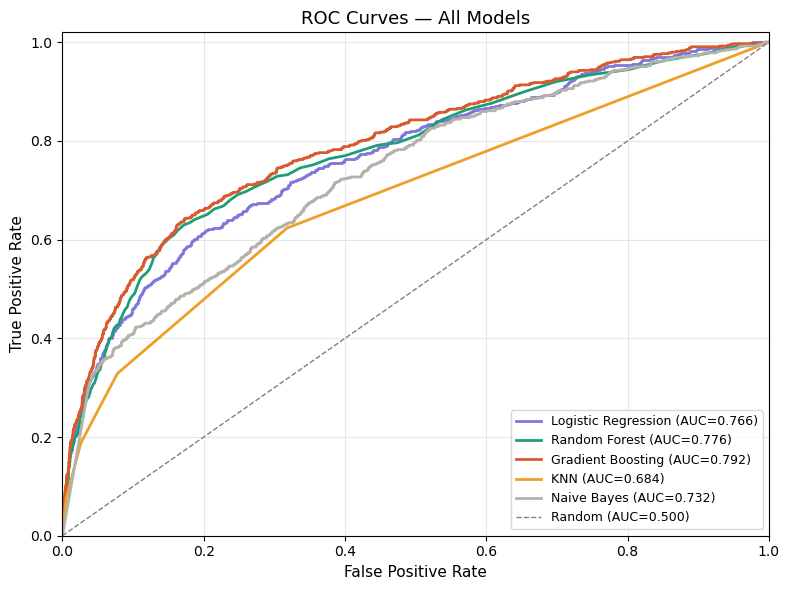

In [ ]:


# ── single ROC curve plot ──────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#7F77DD', '#1D9E75', '#D85A30', '#EF9F27', '#B4B2A9']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr,
            label=f"{name} (AUC={roc_auc:.3f})",
            color=color, linewidth=2)

# random classifier baseline
ax.plot([0, 1], [0, 1],
        linestyle='--', color='grey',
        linewidth=1, label='Random (AUC=0.500)')

ax.set_title('ROC Curves — All Models', fontsize=13)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

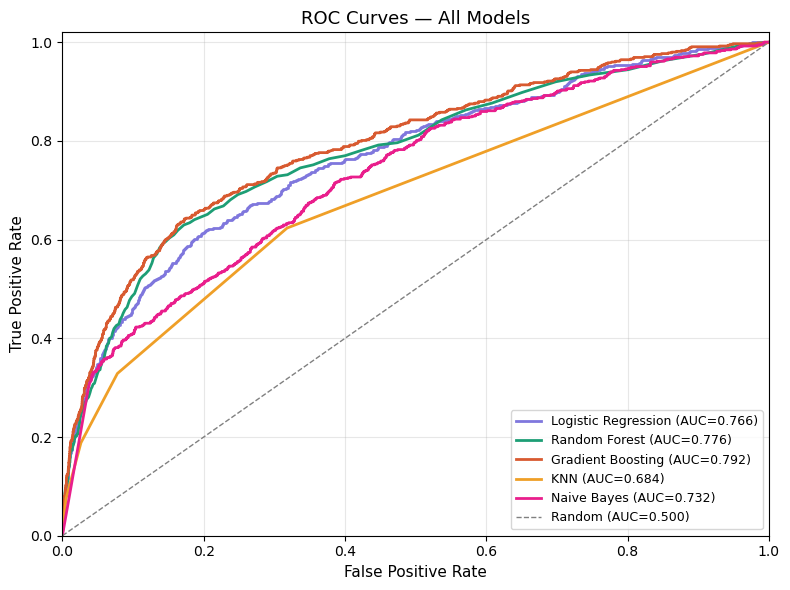

In [ ]:
# ── ROC curve with better colour choices ──────────────
fig, ax = plt.subplots(figsize=(8, 6))

# give Naive Bayes a distinct colour — not grey
colors = {
    'Logistic Regression' : '#7F77DD',   # purple
    'Random Forest'       : '#1D9E75',   # green
    'Gradient Boosting'   : '#D85A30',   # red
    'KNN'                 : '#EF9F27',   # orange
    'Naive Bayes'         : '#E91E8C'    # pink — clearly different
}

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr,
            label=f"{name} (AUC={roc_auc:.3f})",
            color=colors[name], linewidth=2)

# random baseline — dashed grey
ax.plot([0, 1], [0, 1],
        linestyle='--', color='grey',
        linewidth=1, label='Random (AUC=0.500)')

ax.set_title('ROC Curves — All Models', fontsize=13)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

TypeError: 'Axes' object is not subscriptable

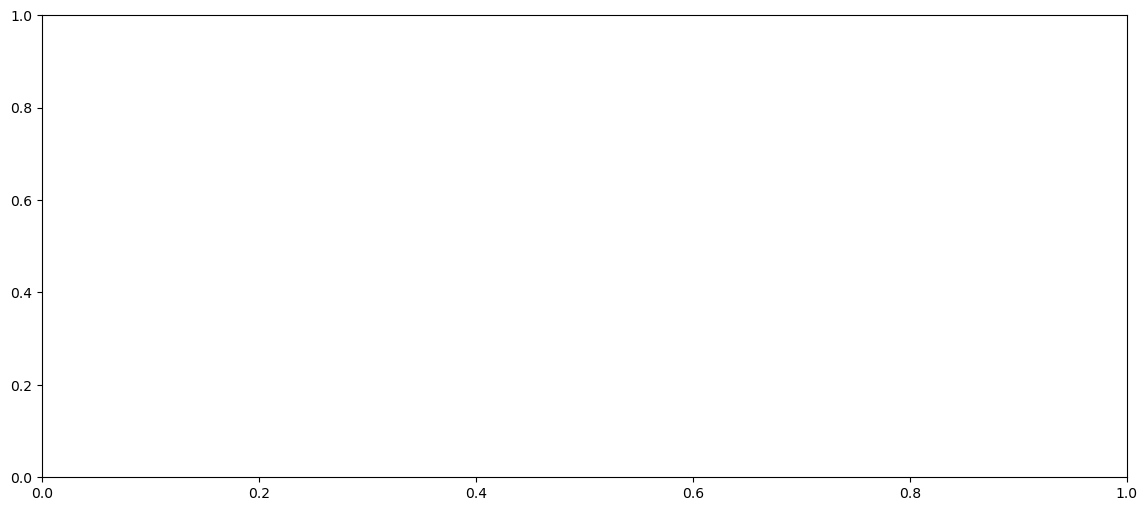

In [ ]:
# fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fig, ax = plt.subplots(figsize=(8, 6))

# ── left plot — ROC curves all models ─────────────────
colors = ['#7F77DD', '#1D9E75', '#D85A30', '#EF9F27', '#B4B2A9']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    roc_auc     = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, 
                 label=f"{name} (AUC={roc_auc:.3f})",
                 color=color, linewidth=2)

# # random classifier baseline
# axes[0].plot([0, 1], [0, 1],  linestyle='--', color='grey',  linewidth=1, label='Random (AUC=0.500)')

# axes[0].set_title('ROC Curves — All Models', fontsize=13)
# axes[0].set_xlabel('False Positive Rate', fontsize=11)
# axes[0].set_ylabel('True Positive Rate', fontsize=11)
# axes[0].legend(loc='lower right', fontsize=9)
# axes[0].set_xlim([0, 1])
# axes[0].set_ylim([0, 1.02])
# axes[0].grid(alpha=0.3)

# # ── right plot — bar chart of ROC-AUC scores ──────────
# model_names = list(results.keys())
# auc_scores  = [res['roc_auc'] for res in results.values()]
# f1_scores   = [res['f1']      for res in results.values()]

# x     = range(len(model_names))
# width = 0.35

# bars1 = axes[1].bar([i - width/2 for i in x], auc_scores, 
#                      width, label='ROC-AUC', 
#                      color='#7F77DD', alpha=0.85)
# bars2 = axes[1].bar([i + width/2 for i in x], f1_scores,  
#                      width, label='F1 Score', 
#                      color='#F0997B', alpha=0.85)

# # add value labels on bars
# for bar in bars1:
#     axes[1].text(bar.get_x() + bar.get_width()/2, 
#                  bar.get_height() + 0.005,
#                  f'{bar.get_height():.3f}', 
#                  ha='center', va='bottom', fontsize=8)

# for bar in bars2:
#     axes[1].text(bar.get_x() + bar.get_width()/2, 
#                  bar.get_height() + 0.005,
#                  f'{bar.get_height():.3f}', 
#                  ha='center', va='bottom', fontsize=8)

# axes[1].set_title('ROC-AUC vs F1 Score by Model', fontsize=13)
# axes[1].set_ylabel('Score', fontsize=11)
# axes[1].set_xticks(list(x))
# axes[1].set_xticklabels(model_names, rotation=30, 
#                          ha='right', fontsize=9)
# axes[1].legend(fontsize=10)
# axes[1].set_ylim([0, 1.0])
# axes[1].axhline(0.5, color='grey', linestyle='--', 
#                 linewidth=1, alpha=0.5)
# axes[1].grid(alpha=0.3, axis='y')

# plt.tight_layout()
# plt.show()


### 3.10 threshold tuning

In [ ]:
y_prob_gb = results['Gradient Boosting']['y_prob']

print("=== threshold tuning — Gradient Boosting ===")
print(f"{'Threshold':>10} {'Accuracy':>10} {'F1':>10} "
      f"{'Recall':>10} {'Precision':>10}")
print("─" * 55)

best_f1, best_thresh = 0, 0.5

for thresh in np.arange(0.5, 0.15, -0.05):
    y_pred_t = (y_prob_gb >= thresh).astype(int)
    acc  = accuracy_score(y_test, y_pred_t)
    f1   = f1_score(y_test, y_pred_t)
    rec  = recall_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t)
    print(f"{thresh:>10.2f} {acc:>10.4f} {f1:>10.4f} "
          f"{rec:>10.4f} {prec:>10.4f}")
    if f1 > best_f1:
        best_f1     = f1
        best_thresh = round(thresh, 2)

print(f"\nBest threshold by F1 : {best_thresh}")
print(f"Best F1 score        : {best_f1:.4f}")

# classification report at best threshold
y_pred_best = (y_prob_gb >= best_thresh).astype(int)
print(f"\nClassification report at threshold={best_thresh}:")
print(classification_report(y_test, y_pred_best,
                             target_names=['TypeA','TypeB']))

=== threshold tuning — Gradient Boosting ===
 Threshold   Accuracy         F1     Recall  Precision
───────────────────────────────────────────────────────
      0.50     0.8907     0.3363     0.2330     0.6040
      0.45     0.8880     0.3548     0.2593     0.5619
      0.40     0.8878     0.3953     0.3086     0.5495
      0.35     0.8839     0.4155     0.3472     0.5172
      0.30     0.8812     0.4385     0.3904     0.5000
      0.25     0.8760     0.4540     0.4336     0.4763
      0.20     0.8663     0.4564     0.4722     0.4416

Best threshold by F1 : 0.2
Best F1 score        : 0.4564

Classification report at threshold=0.2:
              precision    recall  f1-score   support

       TypeA       0.93      0.92      0.92      4805
       TypeB       0.44      0.47      0.46       648

    accuracy                           0.87      5453
   macro avg       0.68      0.70      0.69      5453
weighted avg       0.87      0.87      0.87      5453



### 3.10 SMOTE on GB

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

smote = SMOTE(random_state=42)

# use imblearn Pipeline not sklearn Pipeline
# handles SMOTE correctly — only applies during fit
gb_smote_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote',        smote),
    ('classifier',   GradientBoostingClassifier(
                         n_estimators=200,
                         random_state=42))
])

gb_smote_pipe.fit(X_train, y_train)
y_pred_smote = gb_smote_pipe.predict(X_test)
y_prob_smote = gb_smote_pipe.predict_proba(X_test)[:, 1]

print(f"GB + SMOTE:")
print(f"AUC : {roc_auc_score(y_test, y_prob_smote):.4f}")
print(f"F1  : {f1_score(y_test, y_pred_smote):.4f}")
print(classification_report(y_test, y_pred_smote,
                             target_names=['TypeA','TypeB']))

GB + SMOTE:
AUC : 0.7660
F1  : 0.4188
              precision    recall  f1-score   support

       TypeA       0.92      0.95      0.93      4805
       TypeB       0.48      0.37      0.42       648

    accuracy                           0.88      5453
   macro avg       0.70      0.66      0.68      5453
weighted avg       0.87      0.88      0.87      5453



### 3.11 k folds cross validation 

In [ ]:
# ── K-fold cross validation comparison ────────────────
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# use stratified k-fold to preserve 88/12 class ratio in each fold
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("=== 10-fold stratified cross validation ===")
print(f"{'Model':<25} {'AUC Mean':>10} {'AUC Std':>10} {'F1 Mean':>10} {'F1 Std':>10}")
print("─" * 65)

cv_results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier',   model)
    ])
    
    # AUC scores across 10 folds
    auc_scores = cross_val_score(pipe, X, y, 
                                  cv=skf, 
                                  scoring='roc_auc',
                                  n_jobs=-1)
    
    # F1 scores across 10 folds
    f1_scores  = cross_val_score(pipe, X, y, 
                                  cv=skf, 
                                  scoring='f1',
                                  n_jobs=-1)
    
    cv_results[name] = {
        'auc_mean': auc_scores.mean(),
        'auc_std' : auc_scores.std(),
        'f1_mean' : f1_scores.mean(),
        'f1_std'  : f1_scores.std()
    }
    
    print(f"{name:<25} {auc_scores.mean():>10.4f} "
          f"{auc_scores.std():>10.4f} "
          f"{f1_scores.mean():>10.4f} "
          f"{f1_scores.std():>10.4f}")

print("\n(lower std = more stable/consistent model)")

=== 10-fold stratified cross validation ===
Model                       AUC Mean    AUC Std    F1 Mean     F1 Std
─────────────────────────────────────────────────────────────────
Logistic Regression           0.7660     0.0075     0.3845     0.0093
Random Forest                 0.7752     0.0062     0.2980     0.0017
Gradient Boosting             0.8002     0.0055     0.3467     0.0147
KNN                           0.6725     0.0041     0.2433     0.0070
Naive Bayes                   0.7297     0.0066     0.3865     0.0073

(lower std = more stable/consistent model)


In [ ]:
# ── GridSearchCV hyperparameter tuning on GB ──────────
from sklearn.model_selection import GridSearchCV

print("=== GridSearchCV — Gradient Boosting ===")
print("this may take a few minutes...")

# parameter grid to search
# reduced grid — fewer combinations
# 2 x 2 x 2 x 2 = 16 combinations x 5 folds = 80 fits
# should run in 5-10 min
param_grid = {
    'classifier__n_estimators'  : [100, 200,],
    'classifier__learning_rate' : [0.05, 0.1],
    'classifier__max_depth'     : [3, 4,],
    'classifier__subsample'     : [0.8, 1.0]
}

gb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   GradientBoostingClassifier(random_state=42))
])

grid_search = GridSearchCV(
    gb_pipe,
    param_grid    = param_grid,
    cv            = StratifiedKFold(n_splits=2, shuffle=True, 
                                     random_state=42),
    scoring       = 'roc_auc',
    n_jobs        = -1,
    verbose       = 1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters  : {grid_search.best_params_}")
print(f"Best CV AUC      : {grid_search.best_score_:.4f}")

# evaluate best model on test set
best_gb    = grid_search.best_estimator_
y_pred_gb  = best_gb.predict(X_test)
y_prob_gb  = best_gb.predict_proba(X_test)[:, 1]

print(f"\n=== tuned GB on test set ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"F1       : {f1_score(y_test, y_pred_gb):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_gb):.4f}")
print(f"\n{classification_report(y_test, y_pred_gb, target_names=['TypeA','TypeB'])}")

=== GridSearchCV — Gradient Boosting ===
this may take a few minutes...
Fitting 2 folds for each of 16 candidates, totalling 32 fits


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import fbeta_score, confusion_matrix
import numpy as np

y_prob_gb = results['Gradient Boosting']['y_prob']

print("=== threshold tuning using F2 score — Gradient Boosting ===")
print(f"{'Thresh':>8} {'F2':>8} {'F1':>8} {'Recall':>8} "
      f"{'Precision':>10} {'FN':>6} {'FP':>6}")
print("─" * 60)

best_f2, best_thresh_f2 = 0, 0.5

for thresh in np.arange(0.5, 0.10, -0.05):
    y_pred_t = (y_prob_gb >= thresh).astype(int)
    
    f2   = fbeta_score(y_test, y_pred_t, beta=2)
    f1   = f1_score(y_test, y_pred_t)
    rec  = recall_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t)
    
    cm   = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"{thresh:>8.2f} {f2:>8.4f} {f1:>8.4f} {rec:>8.4f} "
          f"{prec:>10.4f} {fn:>6} {fp:>6}")
    
    if f2 > best_f2:
        best_f2        = f2
        best_thresh_f2 = round(thresh, 2)

print(f"\nBest threshold by F2 : {best_thresh_f2}")
print(f"Best F2 score        : {best_f2:.4f}")

# full report at best F2 threshold
y_pred_f2 = (y_prob_gb >= best_thresh_f2).astype(int)
cm = confusion_matrix(y_test, y_pred_f2)
tn, fp, fn, tp = cm.ravel()

print(f"\n=== at threshold {best_thresh_f2} ===")
print(f"True  Positives (TypeB caught)   : {tp:,}  ← leads found")
print(f"False Negatives (TypeB missed)   : {fn:,}  ← leads missed")
print(f"False Positives (TypeA chased)   : {fp:,}  ← wasted calls")
print(f"True  Negatives (TypeA correctly): {tn:,}")
print(f"\nRecall    : {tp/(tp+fn):.4f}  ← {tp/(tp+fn)*100:.1f}% of leads caught")
print(f"Precision : {tp/(tp+fp):.4f}  ← of calls made {tp/(tp+fp)*100:.1f}% convert")
print(f"\n{classification_report(y_test, y_pred_f2, target_names=['TypeA','TypeB'])}")

=== threshold tuning using F2 score — Gradient Boosting ===
  Thresh       F2       F1   Recall  Precision     FN     FP
────────────────────────────────────────────────────────────
    0.50   0.2657   0.3363   0.2330     0.6040    497     99
    0.45   0.2906   0.3548   0.2593     0.5619    480    131
    0.40   0.3383   0.3953   0.3086     0.5495    448    164
    0.35   0.3717   0.4155   0.3472     0.5172    423    210
    0.30   0.4083   0.4385   0.3904     0.5000    395    253
    0.25   0.4415   0.4540   0.4336     0.4763    367    309
    0.20   0.4658   0.4564   0.4722     0.4416    342    387
    0.15   0.5174   0.4611   0.5633     0.3904    283    570

Best threshold by F2 : 0.15
Best F2 score        : 0.5174

=== at threshold 0.15 ===
True  Positives (TypeB caught)   : 365  ← leads found
False Negatives (TypeB missed)   : 283  ← leads missed
False Positives (TypeA chased)   : 570  ← wasted calls
True  Negatives (TypeA correctly): 4,235

Recall    : 0.5633  ← 56.3% of leads c

In [ ]:
# ── model comparison summary table ────────────────────
from sklearn.metrics import precision_score, recall_score

print(f"{'Model':<25} {'AUC':>7} {'F1':>7} {'Precision':>10} {'Recall':>8} {'Accuracy':>10} {'TP':>6} {'FP':>6} {'TN':>6} {'FN':>6}")
print("─" * 95)

for name, res in results.items():
    cm           = confusion_matrix(y_test, res['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    prec         = precision_score(y_test, res['y_pred'])
    rec          = recall_score(y_test, res['y_pred'])
    
    print(f"{name:<25} {res['roc_auc']:>7.4f} {res['f1']:>7.4f} "
          f"{prec:>10.4f} {rec:>8.4f} {res['accuracy']:>10.4f} "
          f"{tp:>6} {fp:>6} {tn:>6} {fn:>6}")

# ── add GB at tuned threshold 0.20 ────────────────────
y_prob_gb    = results['Gradient Boosting']['y_prob']
y_pred_t020  = (y_prob_gb >= 0.20).astype(int)
cm           = confusion_matrix(y_test, y_pred_t020)
tn, fp, fn, tp = cm.ravel()
prec         = precision_score(y_test, y_pred_t020)
rec          = recall_score(y_test, y_pred_t020)
f1           = f1_score(y_test, y_pred_t020)
acc          = accuracy_score(y_test, y_pred_t020)
auc_score    = roc_auc_score(y_test, y_prob_gb)

print("─" * 95)
print(f"{'GB (threshold=0.20)':<25} {auc_score:>7.4f} {f1:>7.4f} "
      f"{prec:>10.4f} {rec:>8.4f} {acc:>10.4f} "
      f"{tp:>6} {fp:>6} {tn:>6} {fn:>6}")

Model                         AUC      F1  Precision   Recall   Accuracy     TP     FP     TN     FN
───────────────────────────────────────────────────────────────────────────────────────────────
Logistic Regression        0.7660  0.3799     0.2711   0.6343     0.7539    411   1105   3700    237
Random Forest              0.7762  0.2993     0.6028   0.1991     0.8892    129     85   4720    519
Gradient Boosting          0.7920  0.3363     0.6040   0.2330     0.8907    151     99   4706    497


KNN                        0.6843  0.2723     0.4919   0.1883     0.8804    122    126   4679    526
Naive Bayes                0.7325  0.3777     0.3403   0.4244     0.8339    275    533   4272    373
───────────────────────────────────────────────────────────────────────────────────────────────
GB (threshold=0.20)        0.7920  0.4564     0.4416   0.4722     0.8663    306    387   4418    342


In [ ]:
# ── model comparison summary table ────────────────────
from sklearn.metrics import precision_score, recall_score

print(f"{'Model':<25} {'AUC':>7} {'F1':>7} {'Precision':>10} {'Recall':>8} {'Accuracy':>10} {'TP':>6} {'FP':>6} {'TN':>6} {'FN':>6}")
print("─" * 95)

for name, res in results.items():
    cm             = confusion_matrix(y_test, res['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    prec           = precision_score(y_test, res['y_pred'])
    rec            = recall_score(y_test, res['y_pred'])
    
    print(f"{name:<25} {res['roc_auc']:>7.4f} {res['f1']:>7.4f} "
          f"{prec:>10.4f} {rec:>8.4f} {res['accuracy']:>10.4f} "
          f"{tp:>6} {fp:>6} {tn:>6} {fn:>6}")

# ── GB at tuned threshold 0.20 ────────────────────────
y_prob_gb      = results['Gradient Boosting']['y_prob']
y_pred_t020    = (y_prob_gb >= 0.20).astype(int)
cm             = confusion_matrix(y_test, y_pred_t020)
tn, fp, fn, tp = cm.ravel()
prec           = precision_score(y_test, y_pred_t020)
rec            = recall_score(y_test, y_pred_t020)
f1             = f1_score(y_test, y_pred_t020)
acc            = accuracy_score(y_test, y_pred_t020)
auc_score      = roc_auc_score(y_test, y_prob_gb)

print(f"{'GB (threshold=0.20)':<25} {auc_score:>7.4f} {f1:>7.4f} "
      f"{prec:>10.4f} {rec:>8.4f} {acc:>10.4f} "
      f"{tp:>6} {fp:>6} {tn:>6} {fn:>6}")

Model                         AUC      F1  Precision   Recall   Accuracy     TP     FP     TN     FN
───────────────────────────────────────────────────────────────────────────────────────────────
Logistic Regression        0.7660  0.3799     0.2711   0.6343     0.7539    411   1105   3700    237
Random Forest              0.7762  0.2993     0.6028   0.1991     0.8892    129     85   4720    519
Gradient Boosting          0.7920  0.3363     0.6040   0.2330     0.8907    151     99   4706    497
KNN                        0.6843  0.2723     0.4919   0.1883     0.8804    122    126   4679    526
Naive Bayes                0.7325  0.3777     0.3403   0.4244     0.8339    275    533   4272    373
GB (threshold=0.20)        0.7920  0.4564     0.4416   0.4722     0.8663    306    387   4418    342


### 3.12 run model on query xtt file to get probabilities

In [ ]:
# ── predict on query set using df_qry_7 ───────────────

# step 1 — prepare query features (drop target column)
X_query = df_qry_7.drop(columns=['y'])

# confirm shape and columns match training features
print(f"X_query shape  : {X_query.shape}")
print(f"X_train shape  : {X_train.shape}")
print(f"columns match  : {X_query.columns.tolist() == X.columns.tolist()}")

# step 2 — get probabilities using best pipeline
# pipeline applies RobustScaler + OneHotEncoder automatically
best_pipe = results['Gradient Boosting']['pipe']
q_prob    = best_pipe.predict_proba(X_query)[:, 1]

# step 3 — apply threshold 0.20
q_pred_binary = (q_prob >= 0.20).astype(int)

# step 4 — map back to TypeA / TypeB
label_map     = {0: 'TypeA', 1: 'TypeB'}
q_pred_labels = [label_map[p] for p in q_pred_binary]

# step 5 — verify
print(f"\n=== query set predictions ===")
print(f"total rows        : {len(q_pred_labels):,}")
print(f"TypeA predictions : {q_pred_labels.count('TypeA'):,}")
print(f"TypeB predictions : {q_pred_labels.count('TypeB'):,}")
print(f"TypeB rate        : {q_pred_labels.count('TypeB')/len(q_pred_labels)*100:.1f}%")
print(f"\ncounts match query rows : {len(q_pred_labels) == len(df_qry_7)}")
print(f"\nfirst 10 predictions    : {q_pred_labels[:10]}")

# print("=======================")
# y_probs = pipeline.predict_proba(X_query)[:,1]

# print("Min prob:", y_probs.min())
# print("Max prob:", y_probs.max())
# print("Mean prob:", y_probs.mean())

X_query shape  : (17939, 16)
X_train shape  : (21812, 16)
columns match  : True

=== query set predictions ===
total rows        : 17,939
TypeA predictions : 15,790
TypeB predictions : 2,149
TypeB rate        : 12.0%

counts match query rows : True

first 10 predictions    : ['TypeA', 'TypeA', 'TypeA', 'TypeA', 'TypeA', 'TypeA', 'TypeA', 'TypeA', 'TypeA', 'TypeA']


In [ ]:
# ── predict on query set using df_qry_7 ───────────────

# step 1 — prepare query features (drop target column)
X_query = df_qry_7.drop(columns=['y'])

# confirm shape and columns match training features
print(f"X_query shape  : {X_query.shape}")
print(f"X_train shape  : {X_train.shape}")
print(f"columns match  : {X_query.columns.tolist() == X.columns.tolist()}")

# step 2 — get probabilities using best pipeline
best_pipe = results['Gradient Boosting']['pipe']
q_prob    = best_pipe.predict_proba(X_query)[:, 1]

# ── probability sanity check ──────────────────────────
print(f"\n=== probability distribution check ===")
print(f"min prob  : {q_prob.min():.4f}")
print(f"max prob  : {q_prob.max():.4f}")
print(f"mean prob : {q_prob.mean():.4f}")
print(f"std prob  : {q_prob.std():.4f}")

# check for suspiciously narrow range
prob_range = q_prob.max() - q_prob.min()
print(f"prob range: {prob_range:.4f}")
if prob_range < 0.1:
    print("WARNING — very narrow probability range, model may not be discriminating well")
else:
    print("probability range looks healthy ✓")

# distribution of probabilities in buckets
print(f"\nprobability distribution:")
buckets = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
for i in range(len(buckets)-1):
    count = ((q_prob >= buckets[i]) & (q_prob < buckets[i+1])).sum()
    pct   = count / len(q_prob) * 100
    print(f"  {buckets[i]:.1f} - {buckets[i+1]:.1f} : {count:,}  ({pct:.1f}%)")

# step 3 — apply threshold 0.20
q_pred_binary = (q_prob >= 0.20).astype(int)

# step 4 — map back to TypeA / TypeB
label_map     = {0: 'TypeA', 1: 'TypeB'}
q_pred_labels = [label_map[p] for p in q_pred_binary]

# step 5 — verify predictions
print(f"\n=== query set predictions ===")
print(f"total rows        : {len(q_pred_labels):,}")
print(f"TypeA predictions : {q_pred_labels.count('TypeA'):,}")
print(f"TypeB predictions : {q_pred_labels.count('TypeB'):,}")
print(f"TypeB rate        : {q_pred_labels.count('TypeB')/len(q_pred_labels)*100:.1f}%")
print(f"counts match      : {len(q_pred_labels) == len(df_qry_7)}")
print(f"\nfirst 10 predictions : {q_pred_labels[:10]}")

X_query shape  : (17939, 16)
X_train shape  : (21812, 16)
columns match  : True

=== probability distribution check ===
min prob  : 0.0145
max prob  : 0.9752
mean prob : 0.1173
std prob  : 0.1489
prob range: 0.9608
probability range looks healthy ✓

probability distribution:
  0.0 - 0.1 : 12,722  (70.9%)
  0.1 - 0.2 : 3,068  (17.1%)
  0.2 - 0.3 : 587  (3.3%)
  0.3 - 0.4 : 461  (2.6%)
  0.4 - 0.5 : 309  (1.7%)
  0.5 - 0.6 : 250  (1.4%)
  0.6 - 0.7 : 178  (1.0%)
  0.7 - 0.8 : 183  (1.0%)
  0.8 - 0.9 : 138  (0.8%)
  0.9 - 1.0 : 43  (0.2%)

=== query set predictions ===
total rows        : 17,939
TypeA predictions : 15,790
TypeB predictions : 2,149
TypeB rate        : 12.0%
counts match      : True

first 10 predictions : ['TypeA', 'TypeA', 'TypeA', 'TypeA', 'TypeA', 'TypeA', 'TypeA', 'TypeA', 'TypeA', 'TypeA']


### Step 4 - Generate answer file 

In [ ]:

# your student number here
student_number = 'D12345678'   # ← replace with your actual number
file_name      = f"{student_number}.txt"

# save predictions — one per line, no header, no index
pd.Series(q_pred_labels).to_csv(file_name, index=False, header=False)

# ── verify file ───────────────────────────────────────
print(f"=== submission file verification ===")
print(f"file name        : {file_name}")
print(f"file size        : {os.path.getsize(file_name):,} bytes")

# read back and verify
saved = pd.read_csv(file_name, header=None)
print(f"rows in file     : {len(saved):,}  ← must be 17,939")
print(f"unique values    : {saved[0].unique()}")
print(f"TypeA count      : {(saved[0] == 'TypeA').sum():,}")
print(f"TypeB count      : {(saved[0] == 'TypeB').sum():,}")
print(f"\nfirst 10 rows:")
print(saved.head(10).to_string(index=False))
print(f"\nlast 10 rows:")
print(saved.tail(10).to_string(index=False))

=== submission file verification ===
file name        : D12345678.txt
file size        : 125,573 bytes
rows in file     : 17,939  ← must be 17,939
unique values    : ['TypeA' 'TypeB']
TypeA count      : 15,790
TypeB count      : 2,149

first 10 rows:
    0
TypeA
TypeA
TypeA
TypeA
TypeA
TypeA
TypeA
TypeA
TypeA
TypeA

last 10 rows:
    0
TypeA
TypeB
TypeB
TypeB
TypeB
TypeB
TypeB
TypeB
TypeA
TypeB
